In [1]:
library(tidyverse)
library(lme4)
require(ggpattern)
library(stringr)
library(R.matlab)
library(psych)
library(RColorBrewer)
library("ggbeeswarm")
library(see)
library('ggridges')
root_dir = '/data/dian/Dropbox/Stanford_Matters/data/THAL/CCEP/results/explore6_xcorr'#'/Users/dl577/GoogleDrive_symlink/WritingMaterials/My_papers/THAL_writing'
knitr::opts_chunk$set(echo = TRUE, root.dir = root_dir)
figpath = '~/Dropbox/Stanford_Matters/data/THAL/CCEP/Plots/explore6'
fprintf <- function(...)print(sprintf(...))


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: ggpattern

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘ggpattern’”
R.matlab v3.7.0 (2022-08-25 21:52:34 UTC) successfully loaded. See ?R.matlab for help.


Attaching package: ‘R.matlab’


The following objects are 

In [2]:
# load customized color pallete
my_palettes = function(name, n, all_palettes = my_colours, type = c("discrete", "continuous")) {
  palette = all_palettes[[name]]
  if (missing(n)) {
    n = length(palette)
  }
  type = match.arg(type)
  out = switch(type,
               continuous = grDevices::colorRampPalette(palette)(n),
               discrete = palette[1:n]
  )
  structure(out, name = name, class = "palette")
}
# read matlab customize color pallete
cl_path = '~/Dropbox/scripts/PlottingTools/ColourMap_matlab'
cl_pal = readMat(sprintf('%s/%s.mat', cl_path, 'imperfectSpectral')) 
col_vals1 = rgb(cl_pal$cm[,1], cl_pal$cm[,2], cl_pal$cm[,3] )
cl_pal = readMat(sprintf('%s/%s.mat', cl_path, 'imperfectSpectral2')) 
col_vals2 = rgb(cl_pal$cm[,1], cl_pal$cm[,2], cl_pal$cm[,3] )
cl_pal = readMat(sprintf('%s/%s.mat', cl_path, 'Spectral')) 
col_vals3 = rgb(cl_pal$cm[,1], cl_pal$cm[,2], cl_pal$cm[,3] )
cl_pal = readMat(sprintf('%s/%s.mat', cl_path, 'twilight_cyclic')) 
col_vals4 = rgb(cl_pal$cm[,1], cl_pal$cm[,2], cl_pal$cm[,3] )
cl_pal = readMat(sprintf('%s/%s.mat', cl_path, 'viridis')) 
col_vals5 = rgb(cl_pal$cm[,1], cl_pal$cm[,2], cl_pal$cm[,3] )
cl_pal = readMat(sprintf('%s/%s.mat', cl_path, 'rosy')) 
col_vals6 = rgb(cl_pal$cm[,1], cl_pal$cm[,2], cl_pal$cm[,3] )
cl_pal = readMat(sprintf('%s/%s.mat', cl_path, 'blue')) 
col_vals7 = rgb(cl_pal$cm[,1], cl_pal$cm[,2], cl_pal$cm[,3] )   

my_colours = list(imperfectSpectral = col_vals1,
                 imperfectSpectral2 = col_vals2,
                 Spectral = col_vals3,
                 twilight_cyclic = col_vals4,
                 viridis = col_vals5,
                 rosy = col_vals6,
                 blue = col_vals7)

In [3]:
corticalAreas <- c(#'BG', 'AMY',  #subcortical, exclude 'CLT'
                'OFC', 'ACC', 'MFC', 'LFC', 'INS',# frontal # exclude 'FP'
                'TP', 'HPC', 'PHG', 'FG', 'ITG', 'MTG', 'STG',#temporal
                'MCC', 'SM', 'SPL', 'IPL', 'PMC', 'OCC') # parietal
               # 'antTH', 'midTH', 'pstTH')

dat <- read_csv(paste0(root_dir,'/table_CCEPnewpipOutput_wholebrain_anatomical_info_activationRedone4.csv')) %>%
  mutate(xHEMI_code = (MNIout_coord_1*MNIin_coord_1)/abs(MNIout_coord_1*MNIin_coord_1)
        ) %>%
  mutate(xHEMI = case_when(
    xHEMI_code > 0 ~ 'ipsilateral',
    xHEMI_code < 0 ~ 'contralateral',
    xHEMI_code == 0 ~ NA
  ),  Region = case_when(
    JP_label_out %in% c('antTH', 'pstTH', 'midTH') ~ 'Thalamus',
    JP_label_out %in% corticalAreas ~ 'Cortex',
    JP_label_out %in%c('BG', 'AMY') ~ 'Others'
  ) ) %>% mutate(xHEMI = factor(xHEMI, levels = c('ipsilateral', 'contralateral'))) %>%
 filter(umapAct == 1 & sCrossBorder==0 & rCrossBorder==0)%>% 
mutate(FromRegion = Region,
      ToRegion = case_when(
          JP_label_in %in% c('antTH', 'pstTH', 'midTH') ~ 'Thalamus',
          JP_label_in %in% corticalAreas ~ 'Cortex',
          JP_label_in %in%c('BG', 'AMY') ~ 'Others'
      ), stimElecID = paste(subject, stim_chan),
       recordElecID = paste(subject, record_chan),
       stimArea = JP_label_out, recordArea = JP_label_in,
       xHEMI_short = case_when(
       xHEMI == 'ipsilateral' ~ 'ipsi',
       xHEMI == 'contralateral' ~ 'contr'
       ),
       FromRegion_short = case_when(
       FromRegion == 'Thalamus' ~ 'T',
       FromRegion == 'Cortex' ~ 'C'
       ),
       ToRegion_short = case_when(
       ToRegion == 'Thalamus' ~ 'T',
       ToRegion == 'Cortex' ~ 'C'
       ),
       Connection = paste0(FromRegion_short,'->', ToRegion_short, '(', xHEMI_short, ')')
      )

Rows: 275336 Columns: 83
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (19): subject, aSubID, block_name, stim_chan, record_chan, sc1, sc2, rc1...
dbl (64): stim_shank, activated, min_pk_time, prom_pk_time, num_pks, osc_spe...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Compare feature representation between ipsilateral and contralateral stimulations

### Stats for feature-1 representation (r):
"F1 was seen more strongly for ipsilateral than contralateral EPs and earlier for cortical than thalamic ones."

In [17]:
d <- dat %>% filter(Region %in% c('Cortex', 'Thalamus'))

nF <- 1
featureName <- paste0('peak_maxCor_clst', nF)
d['feature'] <- d[featureName]

lm1 = lmer(feature ~ xHEMI +Region+  (1|subject:JP_label_in:record_chan), data=d)
sumy <-summary(lm1)
print(sumy)
lm0 <- lmer(feature ~ Region+  (1|subject:JP_label_in:record_chan), data=d)
aov<-anova(lm0, lm1)
print(aov)

Linear mixed model fit by REML ['lmerMod']
Formula: feature ~ xHEMI + Region + (1 | subject:JP_label_in:record_chan)
   Data: d

REML criterion at convergence: -17509.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.6037 -0.6239  0.1397  0.7370  2.7851 

Random effects:
 Groups                          Name        Variance Std.Dev.
 subject:JP_label_in:record_chan (Intercept) 0.005241 0.07239 
 Residual                                    0.040648 0.20161 
Number of obs: 57881, groups:  subject:JP_label_in:record_chan, 3243

Fixed effects:
                    Estimate Std. Error t value
(Intercept)         0.489045   0.001689  289.50
xHEMIcontralateral -0.112959   0.002351  -48.05
RegionThalamus      0.018752   0.002774    6.76

Correlation of Fixed Effects:
            (Intr) xHEMIc
xHEMIcntrlt -0.269       
RegionThlms -0.208  0.070


refitting model(s) with ML (instead of REML)



Data: d
Models:
lm0: feature ~ Region + (1 | subject:JP_label_in:record_chan)
lm1: feature ~ xHEMI + Region + (1 | subject:JP_label_in:record_chan)
    npar    AIC    BIC logLik deviance  Chisq Df Pr(>Chisq)    
lm0    4 -15269 -15233 7638.6   -15277                         
lm1    5 -17531 -17486 8770.4   -17541 2263.6  1  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


### Stats for feature-1 representation (latency):
"earlier when cortical sites than thalamic sites were stimulated "

In [31]:
thr <- 0.4
d <- dat %>% filter(Region %in% c('Thalamus', 'Cortex') & peak_maxCor_clst1 > thr & time_maxCor_clst1 >10 & time_maxCor_clst1<100)

nF <- 1
featureName <- paste0('time_maxCor_clst', nF)
d['feature'] <- d[featureName]

lm1 = lmer(feature ~  xHEMI +  Region + (1|subject:JP_label_in:record_chan), data=d)
summary(lm1)
lm0 <- lmer(feature ~ xHEMI + (1|subject:JP_label_in:record_chan), data=d)
print(anova(lm0, lm1))

Linear mixed model fit by REML ['lmerMod']
Formula: feature ~ xHEMI + Region + (1 | subject:JP_label_in:record_chan)
   Data: d

REML criterion at convergence: 297519.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.5714 -0.6921 -0.1141  0.5653  4.9458 

Random effects:
 Groups                          Name        Variance Std.Dev.
 subject:JP_label_in:record_chan (Intercept)  14.96    3.868  
 Residual                                    155.79   12.481  
Number of obs: 37444, groups:  subject:JP_label_in:record_chan, 3151

Fixed effects:
                   Estimate Std. Error t value
(Intercept)         36.4369     0.1068 341.291
xHEMIcontralateral   1.7034     0.2046   8.326
RegionThalamus       5.6190     0.2067  27.190

Correlation of Fixed Effects:
            (Intr) xHEMIc
xHEMIcntrlt -0.267       
RegionThlms -0.256  0.065

refitting model(s) with ML (instead of REML)



Data: d
Models:
lm0: feature ~ xHEMI + (1 | subject:JP_label_in:record_chan)
lm1: feature ~ xHEMI + Region + (1 | subject:JP_label_in:record_chan)
    npar    AIC    BIC  logLik deviance  Chisq Df Pr(>Chisq)    
lm0    4 298254 298288 -149123   298246                         
lm1    5 297524 297567 -148757   297514 731.91  1  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


### Stats for F2 ipsilateral vs contralateral EPs 

In [27]:
d <- dat %>% filter(Region %in% c('Cortex', 'Thalamus') )

nF <- 2
featureName <- paste0('peak_maxCor_clst', nF)
d['feature'] <- d[featureName]

lm1 = lmer(feature ~ xHEMI +Region+ (1|subject:JP_label_in:record_chan), data=d)
sumy <-summary(lm1)
print(sumy)
lm0 <- lmer(feature ~ Region+ (1|subject:JP_label_in:record_chan), data=d)
aov<-anova(lm0, lm1)
print(aov)

Linear mixed model fit by REML ['lmerMod']
Formula: feature ~ xHEMI + Region + (1 | subject:JP_label_in:record_chan)
   Data: d

REML criterion at convergence: -37548.1

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.8560 -0.5386  0.1984  0.7188  2.4884 

Random effects:
 Groups                          Name        Variance Std.Dev.
 subject:JP_label_in:record_chan (Intercept) 0.003789 0.06156 
 Residual                                    0.028730 0.16950 
Number of obs: 57881, groups:  subject:JP_label_in:record_chan, 3243

Fixed effects:
                    Estimate Std. Error t value
(Intercept)         0.655338   0.001430 458.222
xHEMIcontralateral -0.088779   0.001978 -44.889
RegionThalamus      0.012772   0.002333   5.475

Correlation of Fixed Effects:
            (Intr) xHEMIc
xHEMIcntrlt -0.267       
RegionThlms -0.207  0.070


refitting model(s) with ML (instead of REML)



Data: d
Models:
lm0: feature ~ Region + (1 | subject:JP_label_in:record_chan)
lm1: feature ~ xHEMI + Region + (1 | subject:JP_label_in:record_chan)
    npar    AIC    BIC logLik deviance  Chisq Df Pr(>Chisq)    
lm0    4 -35592 -35556  17800   -35600                         
lm1    5 -37570 -37526  18790   -37580 1980.8  1  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


### Stats for feature-2 representation (latency):

"earlier when cortical sites than thalamic sites were stimulated"

In [30]:
thr<-0.4
d <- dat %>% filter((Region=='Thalamus' | Region == 'Cortex')& peak_maxCor_clst2 > thr& time_maxCor_clst2<200 & time_maxCor_clst2>70)

nF <- 2
featureName <- paste0('time_maxCor_clst', nF)
d['feature'] <- d[featureName]

lm1 = lmer(feature ~   xHEMI +Region+ +  (1|subject:JP_label_in:record_chan), data=d)
summary(lm1)
lm0 <- lmer(feature ~   xHEMI + (1|subject:JP_label_in:record_chan), data=d)
anova(lm0, lm1)

Linear mixed model fit by REML ['lmerMod']
Formula: feature ~ xHEMI + Region + +(1 | subject:JP_label_in:record_chan)
   Data: d

REML criterion at convergence: 448874.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.6081 -0.7011 -0.1280  0.5620  3.3078 

Random effects:
 Groups                          Name        Variance Std.Dev.
 subject:JP_label_in:record_chan (Intercept)  45.71    6.761  
 Residual                                    607.14   24.640  
Number of obs: 48300, groups:  subject:JP_label_in:record_chan, 3211

Fixed effects:
                   Estimate Std. Error t value
(Intercept)        120.7041     0.1860 648.779
xHEMIcontralateral  -0.4282     0.3251  -1.317
RegionThalamus       8.1828     0.3639  22.489

Correlation of Fixed Effects:
            (Intr) xHEMIc
xHEMIcntrlt -0.299       
RegionThlms -0.250  0.071

refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
lm0,4,449383.6,449418.8,-224687.8,449375.6,NA,NA,NA
lm1,5,448882.6,448926.6,-224436.3,448872.6,503.0038,1,2.110604e-111


#### feature-2 testing for COR-ipsi vs. COR-contr

In [38]:
thr<-0.4
d <- dat %>% filter(Region=='Cortex' & ToRegion == 'Cortex' &
                 peak_maxCor_clst2 > thr& time_maxCor_clst2<200 & time_maxCor_clst2>70)

nF <- 2
featureName <- paste0('time_maxCor_clst', nF)
d['feature'] <- d[featureName]

lm1 = lmer(feature ~  xHEMI +  (1|subject:JP_label_in:record_chan), data=d)
summary(lm1)
lm0 <- lmer(feature ~ (1|subject:JP_label_in:record_chan), data=d)
anova(lm0, lm1)

Linear mixed model fit by REML ['lmerMod']
Formula: feature ~ xHEMI + (1 | subject:JP_label_in:record_chan)
   Data: d

REML criterion at convergence: 333650

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.3800 -0.6900 -0.1279  0.5372  3.3794 

Random effects:
 Groups                          Name        Variance Std.Dev.
 subject:JP_label_in:record_chan (Intercept)  48.7     6.979  
 Residual                                    595.7    24.408  
Number of obs: 35955, groups:  subject:JP_label_in:record_chan, 2740

Fixed effects:
                    Estimate Std. Error t value
(Intercept)        1.205e+02  2.032e-01 593.095
xHEMIcontralateral 1.437e-03  3.775e-01   0.004

Correlation of Fixed Effects:
            (Intr)
xHEMIcntrlt -0.293

refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
lm0,3,333654.4,333679.9,-166824.2,333648.4,NA,NA,NA
lm1,4,333656.4,333690.4,-166824.2,333648.4,1.176534e-05,1,0.9972632


### Stats for F3 peak

In [42]:

d <- dat %>% filter(Region == 'Thalamus' )

nF <- 3
featureName <- paste0('peak_maxCor_clst', nF)
d['feature'] <- d[featureName]

lm1 = lmer(feature ~  xHEMI + (1|subject:JP_label_in:record_chan), data=d)
summary(lm1)
lm0 <- lmer(feature ~ 1+(1|subject:JP_label_in:record_chan), data=d)
anova(lm0, lm1)

Linear mixed model fit by REML ['lmerMod']
Formula: feature ~ xHEMI + (1 | subject:JP_label_in:record_chan)
   Data: d

REML criterion at convergence: -3280.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.7670 -0.4158  0.2361  0.6170  2.2515 

Random effects:
 Groups                          Name        Variance Std.Dev.
 subject:JP_label_in:record_chan (Intercept) 0.01149  0.1072  
 Residual                                    0.02691  0.1641  
Number of obs: 6397, groups:  subject:JP_label_in:record_chan, 2435

Fixed effects:
                    Estimate Std. Error t value
(Intercept)         0.651356   0.003247 200.610
xHEMIcontralateral -0.021397   0.007081  -3.022

Correlation of Fixed Effects:
            (Intr)
xHEMIcntrlt -0.223

refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
lm0,3,-3282.927,-3262.636,1644.464,-3288.927,NA,NA,NA
lm1,4,-3289.924,-3262.870,1648.962,-3297.924,8.997315,1,0.002703766


In [43]:
length(unique(d$subject))

[1] 25

In [41]:
p.adjust(rep(0.0027, 6))

[1] 0.0162 0.0162 0.0162 0.0162 0.0162 0.0162

### Stats for feature-3 representation (latency):

In [47]:
thr<-0.5
d <- dat %>% filter(Region == 'Thalamus' &time_maxCor_clst3> 200 & peak_maxCor_clst3 > thr)

nF <- 3
featureName <- paste0('time_maxCor_clst', nF)
d['feature'] <- d[featureName]

lm1 = lmer(feature ~  xHEMI + (1|subject:JP_label_in:record_chan), data=d)
summary(lm1)
lm0 <- lmer(feature ~ 1+(1|subject:JP_label_in:record_chan), data=d)
anova(lm0, lm1)

Linear mixed model fit by REML ['lmerMod']
Formula: feature ~ xHEMI + (1 | subject:JP_label_in:record_chan)
   Data: d

REML criterion at convergence: 33195.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.5753 -0.7536 -0.1620  0.5054  5.0423 

Random effects:
 Groups                          Name        Variance Std.Dev.
 subject:JP_label_in:record_chan (Intercept)  217.2   14.74   
 Residual                                    2369.4   48.68   
Number of obs: 3106, groups:  subject:JP_label_in:record_chan, 1593

Fixed effects:
                   Estimate Std. Error t value
(Intercept)         267.474      1.034 258.772
xHEMIcontralateral   -5.034      2.699  -1.865

Correlation of Fixed Effects:
            (Intr)
xHEMIcntrlt -0.329

refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
lm0,3,33210.34,33228.46,-16602.17,33204.34,NA,NA,NA
lm1,4,33208.87,33233.03,-16600.43,33200.87,3.471045,1,0.06245186


###  F1 comparison between COR vs THAL recording sites from cortical stimualtions
"the stimulation of a large number of cortical seeds caused responses in the thalamus that were earlier and stronger compared to the responses in cortical targets caused by the stimulation of the same cortical seeds within the same individuals"

In [77]:
thr <- 0.4
d <- dat %>% filter(FromRegion =='Cortex' &
                    ToRegion %in% c('Cortex', 'Thalamus' ))

nF <- 1
featureName <- paste0('peak_maxCor_clst', nF)
d['feature'] <- d[featureName]

lm1 = lmer(feature ~  xHEMI + ToRegion + (1|subject:JP_label_out:stim_chan), data=d)
summary(lm1)
lm0 <- lmer(feature ~ xHEMI + (1|subject:JP_label_out:stim_chan), data=d)
print(anova(lm0, lm1))

Linear mixed model fit by REML ['lmerMod']
Formula: feature ~ xHEMI + ToRegion + (1 | subject:JP_label_out:stim_chan)
   Data: d

REML criterion at convergence: -14067.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.7625 -0.6350  0.1392  0.7411  2.7693 

Random effects:
 Groups                         Name        Variance Std.Dev.
 subject:JP_label_out:stim_chan (Intercept) 0.006626 0.0814  
 Residual                                   0.041642 0.2041  
Number of obs: 48446, groups:  subject:JP_label_out:stim_chan, 1387

Fixed effects:
                    Estimate Std. Error t value
(Intercept)         0.476329   0.002517  189.27
xHEMIcontralateral -0.110932   0.002567  -43.22
ToRegionThalamus    0.056067   0.003083   18.19

Correlation of Fixed Effects:
            (Intr) xHEMIc
xHEMIcntrlt -0.186       
ToRegnThlms -0.115 -0.092

refitting model(s) with ML (instead of REML)



Data: d
Models:
lm0: feature ~ xHEMI + (1 | subject:JP_label_out:stim_chan)
lm1: feature ~ xHEMI + ToRegion + (1 | subject:JP_label_out:stim_chan)
    npar    AIC    BIC logLik deviance  Chisq Df Pr(>Chisq)    
lm0    4 -13760 -13725 6884.1   -13768                         
lm1    5 -14088 -14044 7048.9   -14098 329.54  1  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [79]:
length(unique(d$subject))

[1] 26

In [78]:
thr <- 0.4
d <- dat %>% filter(FromRegion =='Cortex' &
                    ToRegion %in% c('Cortex', 'Thalamus' )&
                    peak_maxCor_clst1 > thr & time_maxCor_clst1 >10 & time_maxCor_clst1<100)

nF <- 1
featureName <- paste0('time_maxCor_clst', nF)
d['feature'] <- d[featureName]

lm1 = lmer(feature ~  xHEMI + ToRegion + (1|subject:JP_label_out:stim_chan), data=d)
summary(lm1)
lm0 <- lmer(feature ~ xHEMI + (1|subject:JP_label_out:stim_chan), data=d)
print(anova(lm0, lm1))

Linear mixed model fit by REML ['lmerMod']
Formula: feature ~ xHEMI + ToRegion + (1 | subject:JP_label_out:stim_chan)
   Data: d

REML criterion at convergence: 243339.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.8610 -0.6781 -0.0983  0.5654  5.2376 

Random effects:
 Groups                         Name        Variance Std.Dev.
 subject:JP_label_out:stim_chan (Intercept)  18.34    4.282  
 Residual                                   143.50   11.979  
Number of obs: 30965, groups:  subject:JP_label_out:stim_chan, 1378

Fixed effects:
                   Estimate Std. Error t value
(Intercept)         36.3668     0.1465 248.318
xHEMIcontralateral   1.1626     0.2146   5.418
ToRegionThalamus    -2.7892     0.2189 -12.739

Correlation of Fixed Effects:
            (Intr) xHEMIc
xHEMIcntrlt -0.176       
ToRegnThlms -0.154 -0.108

refitting model(s) with ML (instead of REML)



Data: d
Models:
lm0: feature ~ xHEMI + (1 | subject:JP_label_out:stim_chan)
lm1: feature ~ xHEMI + ToRegion + (1 | subject:JP_label_out:stim_chan)
    npar    AIC    BIC  logLik deviance  Chisq Df Pr(>Chisq)    
lm0    4 243505 243538 -121748   243497                         
lm1    5 243345 243387 -121668   243335 161.65  1  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [84]:
thr <- 0.4
d <- dat %>% filter(FromRegion =='Cortex' & xHEMI == 'ipsi' &
                    ToRegion %in% c('Cortex', 'Thalamus' ))

nF <- 1
featureName <- paste0('peak_maxCor_clst', nF)
d['feature'] <- d[featureName]

lm1 = lmer(feature ~  ToRegion + (1|subject:JP_label_out:stim_chan), data=d)
summary(lm1)
lm0 <- lmer(feature ~ 1+(1|subject:JP_label_out:stim_chan), data=d)
print(anova(lm0, lm1))

ERROR: Error in lme4::lFormula(formula = feature ~ ToRegion + (1 | subject:JP_label_out:stim_chan), : 0 (non-NA) cases


###  F3 comparison between COR vs THAL stimulation sites in all recording sites
"the latency of the F3 responses caused by thalamic stimulations was significantly earlier than the others"

In [81]:
thr <- 0.5
d <- dat %>% filter(
                    FromRegion %in% c('Cortex', 'Thalamus' )&
                    peak_maxCor_clst1 > thr & time_maxCor_clst3 >200 & time_maxCor_clst3<500)

nF <- 3
featureName <- paste0('time_maxCor_clst', nF)
d['feature'] <- d[featureName]

lm1 = lmer(feature ~  xHEMI + FromRegion + (1|subject:JP_label_in:record_chan), data=d)
summary(lm1)
lm0 <- lmer(feature ~ xHEMI + (1|subject:JP_label_in:record_chan), data=d)
print(anova(lm0, lm1))

Linear mixed model fit by REML ['lmerMod']
Formula: feature ~ xHEMI + FromRegion + (1 | subject:JP_label_in:record_chan)
   Data: d

REML criterion at convergence: 238744.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.9029 -0.7992 -0.1152  0.7053  3.1126 

Random effects:
 Groups                          Name        Variance Std.Dev.
 subject:JP_label_in:record_chan (Intercept)  306.6   17.51   
 Residual                                    5335.4   73.04   
Number of obs: 20823, groups:  subject:JP_label_in:record_chan, 3041

Fixed effects:
                   Estimate Std. Error t value
(Intercept)        319.9721     0.6846 467.368
xHEMIcontralateral  -4.4244     1.6322  -2.711
FromRegionThalamus -36.3652     1.6859 -21.570

Correlation of Fixed Effects:
            (Intr) xHEMIc
xHEMIcntrlt -0.304       
FrmRgnThlms -0.291  0.069

refitting model(s) with ML (instead of REML)



Data: d
Models:
lm0: feature ~ xHEMI + (1 | subject:JP_label_in:record_chan)
lm1: feature ~ xHEMI + FromRegion + (1 | subject:JP_label_in:record_chan)
    npar    AIC    BIC  logLik deviance  Chisq Df Pr(>Chisq)    
lm0    4 239219 239251 -119606   239211                         
lm1    5 238761 238801 -119376   238751 459.98  1  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


## Post-hoc comparisons

In [29]:
rownames(sumy_$coefficients)[2]

[1] "ToRegionThalamus"

In [30]:
grepl('ToRegion', rownames(sumy_$coefficients))
unlist(str_split(rownames(sumy_$coefficients)[2], 'ToRegion'))[2]

[1] FALSE  TRUE

[1] "Thalamus"

In [330]:
length(unique(d_$FromRegion))

[1] 2

In [333]:
 featureNames = c('peak_maxCor_clst1','time_maxCor_clst1',
                 'peak_maxCor_clst2','time_maxCor_clst2',
                 'peak_maxCor_clst3','time_maxCor_clst3')

hemis <- c('ipsi', 'contr')
from_regions <- c('C', 'T')
to_regions <- c('C', 'T')

t_comp <- c()
t_nobs <- c()
t_nrandomgrps <- c()
t_beta <- c()
t_tstat <- c()
t_dBIC <- c()
t_dAIC <- c()
t_Chisq <- c()
t_p <- c()

#[!is.na(d$Region),]
for (featureName in featureNames){


    if(grepl('1', featureName)){
        peakRange <- c(10, 75)
        thr<-0.4
        nF <- '1'
    }
    else if (grepl('2', featureName)){
        peakRange <- c(76,165)
        thr<-0.4
        nF <- '2'}
    else if (grepl('3', featureName)){
        peakRange <- c(166,500)
        thr<-0.5
        nF <- '3'}

d<-dat%>% filter( ((!!as.symbol(paste0('peak_maxCor_clst', nF))) > thr) &
                    ((!!as.symbol(paste0('time_maxCor_clst', nF)))<peakRange[2] &
                     (!!as.symbol(paste0('time_maxCor_clst', nF)))>peakRange[1]))

d['feature'] <- d[featureName]
###############################################################
    ##  -------> part 1. Comparing between hemispheres -------> 
for(f_region in from_regions){
    for(t_region in to_regions){
  contrast_grp1 = hemis[1]
  contrast_grp2 = hemis[2]
  comparison <- sprintf('%s->%s(%s) vs. %s->%s(%s), %s', 
                        f_region, t_region, contrast_grp1, 
                        f_region, t_region, contrast_grp2,  featureName)
  print(comparison)

  d_ <- d %>% filter(FromRegion_short == f_region & ToRegion_short == t_region)

  lm_ = lmer(feature ~ xHEMI_short  + (1|subject:stimArea:stimElecID) + (1|subject:recordArea)+ (1|subject), d_, na.action = na.omit)
  lm0_ = lmer(feature ~ 1+ (1|subject:stimArea:stimElecID) + (1|subject:recordArea)+ (1|subject), d_, na.action = na.omit)
  sumy_ = summary(lm_)
  aov_ = anova( lm0_, lm_)
    
    randomEffects <- c()
 for (ir in 1:length(sumy_$ngrps)){
    randomEffects <- c(randomEffects, 
                       sprintf('%s:%d',names(sumy_$ngrps)[ir],
                            as.matrix(sumy_$ngrps)[ir]))
    }
        
     # sort contrast order
    fixed_effects = rownames(sumy_$coefficients)
    fe_interest = 'xHEMI_short'
    fe_tested = unlist(str_split(fixed_effects[grepl(fe_interest, fixed_effects)], fe_interest))[2]
    if (fe_tested != contrast_grp1){
        toreverse = -1
    }else{toreverse = 1}
    
  # write value
  t_comp  <- c(t_comp, comparison)
  t_nobs <-  c(t_nobs, nObs=dim(d_)[1])
  t_nrandomgrps <- c(t_nrandomgrps, 
                    paste0(randomEffects, collapse = ", "))
  t_beta  <- c(t_beta,  sumy_$coefficients[2,1] * toreverse)
  t_tstat <- c(t_tstat, sumy_$coefficients[2,3] * toreverse)
  t_dAIC  <- c(t_dAIC,  aov_$AIC[1]- aov_$AIC[2])
  t_dBIC  <- c(t_dBIC,  aov_$BIC[1]- aov_$BIC[2])
  t_Chisq <- c(t_Chisq, aov_$Chisq[2])
  t_p     <- c(t_p,     aov_$`Pr(>Chisq)`[2])
}}

   ############################################################### 
    ## -------> part 2: Comparing between regions -------> 
 regions_tocompare <- c()
    regions_tocompare[1] <- sprintf('%s->%s vs. %s->%s', from_regions[1], to_regions[1], from_regions[2],to_regions[1])
    regions_tocompare[2] <- sprintf('%s->%s vs. %s->%s', from_regions[1], to_regions[2], from_regions[2],to_regions[2])
    regions_tocompare[3] <- sprintf('%s->%s vs. %s->%s', from_regions[1], to_regions[1], from_regions[1],to_regions[2])
    regions_tocompare[4] <- sprintf('%s->%s vs. %s->%s', from_regions[2], to_regions[1], from_regions[2],to_regions[2])
    regions_tocompare[5] <- sprintf('%s->%s vs. %s->%s', from_regions[1], to_regions[2], from_regions[2],to_regions[1])
    regions_tocompare[6] <- sprintf('%s->%s vs. %s->%s', from_regions[1], to_regions[1], from_regions[2],to_regions[2])
    
    for (hemi in hemis){
        for (cregion in regions_tocompare){
            
            conn1 = unlist(str_split(cregion, ' vs. '))[1]
            conn2 = unlist(str_split(cregion, ' vs. '))[2]
            f_region1 = unlist(str_split(conn1, '->'))[1]
            t_region1 = unlist(str_split(conn1, '->'))[2]
            f_region2 = unlist(str_split(conn2, '->'))[1]
            t_region2 = unlist(str_split(conn2, '->'))[2]
            
    comparison <- sprintf('%s->%s(%s) vs. %s->%s(%s), %s', 
                        f_region1, t_region1, hemi, 
                        f_region2, t_region2, hemi,  featureName)
    
  print(comparison)

  d_ <- d %>% filter(xHEMI_short == hemi & 
                     FromRegion_short %in% c(f_region1, f_region2) &
                     ToRegion_short %in% c(t_region1, t_region2) )

  if (f_region1 == f_region2){
      contrast_grp1 = t_region1
      contrast_grp2 = t_region2
      fe_interest = 'ToRegion_short'
      lm_ = lmer(feature ~ ToRegion_short  + (1|subject:stimArea:stimElecID) + (1|subject:recordArea) + (1|subject), d_, na.action = na.omit)
      lm0_ = lmer(feature ~ 1+ (1|subject:stimArea:stimElecID) + (1|subject:recordArea) + (1|subject), d_, na.action = na.omit)
  } else{
      contrast_grp1 = f_region1
      contrast_grp2 = f_region2
      fe_interest = 'FromRegion_short'
      lm_ = lmer(feature ~ FromRegion_short  + (1|subject:recordArea:recordElecID) + (1|subject:stimArea) + (1|subject), d_, na.action = na.omit)
      lm0_ = lmer(feature ~ 1+(1|subject:recordArea:recordElecID) + (1|subject:stimArea) + (1|subject), d_, na.action = na.omit)   
  }          
            
  sumy_ = summary(lm_)
  aov_ = anova( lm0_, lm_)
            
    randomEffects <- c()
 for (ir in 1:length(sumy_$ngrps)){
    randomEffects <- c(randomEffects, 
                       sprintf('%s:%d',names(sumy_$ngrps)[ir],
                            as.matrix(sumy_$ngrps)[ir]))
    }
                
     # sort contrast order
    fixed_effects = rownames(sumy_$coefficients)
    fe_tested = unlist(str_split(fixed_effects[grepl(fe_interest, fixed_effects)], fe_interest))[2]
    if (fe_tested != contrast_grp1){
        #print(fe_tested)
        toreverse = -1
    }else{toreverse = 1}
            
  # write value
  t_comp  <- c(t_comp, comparison)
  t_nobs <-  c(t_nobs, nObs=dim(d_)[1])
  t_nrandomgrps <- c(t_nrandomgrps, 
                    paste0(randomEffects, collapse = ", "))
  t_beta  <- c(t_beta,  sumy_$coefficients[2,1] * toreverse)
  t_tstat <- c(t_tstat, sumy_$coefficients[2,3] * toreverse)
  t_dAIC  <- c(t_dAIC,  aov_$AIC[1]- aov_$AIC[2])
  t_dBIC  <- c(t_dBIC,  aov_$BIC[1]- aov_$BIC[2])
  t_Chisq <- c(t_Chisq, aov_$Chisq[2])
  t_p     <- c(t_p,     aov_$`Pr(>Chisq)`[2])
}
}
 ############################################################### 
    ## -------> part 3: Hypothesis driven - special comparison -------> 
contrast_grps1 <- c('T->C(ipsi)', 'C->C(contr)')
contrast_grps2 <- c('T->T(contr)','T->C(ipsi)')

for (ic in 1:2){
    contrast_grp1 = contrast_grps1[ic]
    contrast_grp2 = contrast_grps2[ic]

    comparison <- sprintf('#%s vs. %s, %s', contrast_grp1, contrast_grp2,  featureName)
    d_ <- d %>% filter(Connection %in%(c(contrast_grp1, contrast_grp2)))
    fe_interest = 'Connection'
    
    if ((length(unique(d_$FromRegion)) == 1) && (length(unique(d_$ToRegion)) > 1)){
        lm_ = lmer(feature ~  Connection + (1|subject:stimArea:stimElecID) + (1|subject:recordArea) + (1|subject), d_, na.action = na.omit)  
        lm0_ = lmer(feature ~  1 + (1|subject:stimArea:stimElecID) + (1|subject:recordArea) + (1|subject), d_, na.action = na.omit)}
    else if ((length(unique(d_$FromRegion)) >1) && (length(unique(d_$ToRegion)) == 1)){
        lm_ = lmer(feature ~  Connection + (1|subject:stimArea) + (1|subject:recordArea:recordElecID) + (1|subject), d_, na.action = na.omit)  
        lm0_ = lmer(feature ~  1 + (1|subject:stimArea) + (1|subject:recordArea:recordElecID) + (1|subject), d_, na.action = na.omit)
        }else{
         lm_ = lmer(feature ~  Connection + (1|subject:stimArea) + (1|subject:recordArea) + (1|subject), d_, na.action = na.omit)  
        lm0_ = lmer(feature ~  1 + (1|subject:stimArea) + (1|subject:recordArea) + (1|subject), d_, na.action = na.omit)
    }

    sumy_ = summary(lm_)
    aov_ = anova( lm0_, lm_)

    randomEffects <- c()
    for (ir in 1:length(sumy_$ngrps)){
    randomEffects <- c(randomEffects, 
                       sprintf('%s:%d',names(sumy_$ngrps)[ir],
                            as.matrix(sumy_$ngrps)[ir]))
    }

    # sort contrast order
    fixed_effects = rownames(sumy_$coefficients)
    fe_tested = unlist(str_split(fixed_effects[grepl(fe_interest, fixed_effects)], fe_interest))[2]
    if (fe_tested != contrast_grp1){
    # print(fe_tested)
    toreverse = -1
    }else{toreverse = 1}

    # write value
    t_comp  <- c(t_comp, comparison)
    t_nobs <-  c(t_nobs, nObs=dim(d_)[1])
    t_nrandomgrps <- c(t_nrandomgrps, 
                paste0(randomEffects, collapse = ", "))
    t_beta  <- c(t_beta,  sumy_$coefficients[2,1] * toreverse)
    t_tstat <- c(t_tstat, sumy_$coefficients[2,3] * toreverse)
    t_dAIC  <- c(t_dAIC,  aov_$AIC[1]- aov_$AIC[2])
    t_dBIC  <- c(t_dBIC,  aov_$BIC[1]- aov_$BIC[2])
    t_Chisq <- c(t_Chisq, aov_$Chisq[2])
    t_p     <- c(t_p,     aov_$`Pr(>Chisq)`[2])    
    }
#--------------------------------------------------------------  
## end of the loop for testing all features
    }
############################################################### 
## Write table
postHocTable <- data.frame(
  comparison = t_comp,
  beta = t_beta,
  nObs = t_nobs,
  nRandomGrps = t_nrandomgrps,
  tstat = t_tstat,
  dAIC = t_dAIC,
  dBIC = t_dBIC,
  Chisq = t_Chisq,
  p = t_p
    )
p_adj = p.adjust(t_p, method="fdr")
postHocTable <- postHocTable%>% mutate(p_adj = p_adj)%>% 
  mutate(across(where(is.numeric), ~ round(., digits = 2)))
postHocTable
csvname <- sprintf('%s/postHocTable_%s_xHEMI-CORTHAL-SepToRegions.csv', root_dir, 'allfeatures')
write_csv(postHocTable, csvname)

[1] "C->C(ipsi) vs. C->C(contr), peak_maxCor_clst1"


refitting model(s) with ML (instead of REML)



[1] "C->T(ipsi) vs. C->T(contr), peak_maxCor_clst1"


refitting model(s) with ML (instead of REML)



[1] "T->C(ipsi) vs. T->C(contr), peak_maxCor_clst1"


...

[1] "C->T(contr) vs. T->C(contr), time_maxCor_clst3"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“unable to evaluate scaled gradient”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge: degenerate  Hessian with 1 negative eigenvalues”
refitting model(s) with ML (instead of REML)



[1] "C->C(contr) vs. T->T(contr), time_maxCor_clst3"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“unable to evaluate scaled gradient”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge: degenerate  Hessian with 1 negative eigenvalues”
refitting model(s) with ML (instead of REML)

refitting model(s) with ML (instead of REML)

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

refitting model(s) with ML (instead of REML)



comparison,beta,nObs,nRandomGrps,tstat,dAIC,dBIC,Chisq,p,p_adj
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"C->C(ipsi) vs. C->C(contr), peak_maxCor_clst1",0.02,27005,"subject:stimArea:stimElecID:1376, subject:recordArea:284, subject:26",9.92,96.05,87.85,98.05,0.00,0.00
"C->T(ipsi) vs. C->T(contr), peak_maxCor_clst1",0.03,3528,"subject:stimArea:stimElecID:1044, subject:recordArea:59, subject:26",8.03,61.95,55.78,63.95,0.00,0.00
"T->C(ipsi) vs. T->C(contr), peak_maxCor_clst1",0.08,3655,"subject:recordArea:248, subject:stimArea:stimElecID:172, subject:25",10.98,116.16,109.96,118.16,0.00,0.00
"T->T(ipsi) vs. T->T(contr), peak_maxCor_clst1",0.07,252,"subject:stimArea:stimElecID:106, subject:recordArea:48, subject:21",4.85,19.61,16.08,21.61,0.00,0.00
"C->C(ipsi) vs. T->C(ipsi), peak_maxCor_clst1",0.00,27063,"subject:recordArea:recordElecID:2699, subject:stimArea:319, subject:26",0.95,-1.09,-9.30,0.91,0.34,0.43
"C->T(ipsi) vs. T->T(ipsi), peak_maxCor_clst1",-0.01,2865,"subject:stimArea:293, subject:recordArea:recordElecID:241, subject:26",-0.62,-1.61,-7.58,0.39,0.53,0.63
"C->C(ipsi) vs. C->T(ipsi), peak_maxCor_clst1",-0.01,26308,"subject:stimArea:stimElecID:1372, subject:recordArea:340, subject:26",-2.76,5.45,-2.73,7.45,0.01,0.01
"T->C(ipsi) vs. T->T(ipsi), peak_maxCor_clst1",-0.02,3620,"subject:recordArea:293, subject:stimArea:stimElecID:172, subject:25",-2.10,2.40,-3.79,4.40,0.04,0.06
"C->T(ipsi) vs. T->C(ipsi), peak_maxCor_clst1",0.00,29928,"subject:recordArea:recordElecID:2940, subject:stimArea:319, subject:26",0.93,-1.12,-9.43,0.88,0.35,0.43


In [334]:
postHocTable

comparison,beta,nObs,nRandomGrps,tstat,dAIC,dBIC,Chisq,p,p_adj
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"C->C(ipsi) vs. C->C(contr), peak_maxCor_clst1",0.02,27005,"subject:stimArea:stimElecID:1376, subject:recordArea:284, subject:26",9.92,96.05,87.85,98.05,0.00,0.00
"C->T(ipsi) vs. C->T(contr), peak_maxCor_clst1",0.03,3528,"subject:stimArea:stimElecID:1044, subject:recordArea:59, subject:26",8.03,61.95,55.78,63.95,0.00,0.00
"T->C(ipsi) vs. T->C(contr), peak_maxCor_clst1",0.08,3655,"subject:recordArea:248, subject:stimArea:stimElecID:172, subject:25",10.98,116.16,109.96,118.16,0.00,0.00
"T->T(ipsi) vs. T->T(contr), peak_maxCor_clst1",0.07,252,"subject:stimArea:stimElecID:106, subject:recordArea:48, subject:21",4.85,19.61,16.08,21.61,0.00,0.00
"C->C(ipsi) vs. T->C(ipsi), peak_maxCor_clst1",0.00,27063,"subject:recordArea:recordElecID:2699, subject:stimArea:319, subject:26",0.95,-1.09,-9.30,0.91,0.34,0.43
"C->T(ipsi) vs. T->T(ipsi), peak_maxCor_clst1",-0.01,2865,"subject:stimArea:293, subject:recordArea:recordElecID:241, subject:26",-0.62,-1.61,-7.58,0.39,0.53,0.63
"C->C(ipsi) vs. C->T(ipsi), peak_maxCor_clst1",-0.01,26308,"subject:stimArea:stimElecID:1372, subject:recordArea:340, subject:26",-2.76,5.45,-2.73,7.45,0.01,0.01
"T->C(ipsi) vs. T->T(ipsi), peak_maxCor_clst1",-0.02,3620,"subject:recordArea:293, subject:stimArea:stimElecID:172, subject:25",-2.10,2.40,-3.79,4.40,0.04,0.06
"C->T(ipsi) vs. T->C(ipsi), peak_maxCor_clst1",0.00,29928,"subject:recordArea:recordElecID:2940, subject:stimArea:319, subject:26",0.93,-1.12,-9.43,0.88,0.35,0.43


### All main effects of the intercepts

In [529]:
dat_ <- dat %>% filter(!is.na(FromRegion_short) & !is.na(ToRegion_short)) %>% 
mutate(Connection = factor(Connection, levels = c(
    'T->C(ipsi)', 'T->C(contr)', 
    'C->T(ipsi)', 'C->T(contr)', 
    'C->C(ipsi)', 'C->C(contr)', 
    'T->T(ipsi)', 'T->T(contr)'
    
))) %>% filter(!is.na(ToRegion_short) | !is.na(FromRegion_short)) %>% mutate(connAreas = paste0(JP_label_out,'->', JP_label_in))

d1<- dat_%>% filter(peak_maxCor_clst1>0.4 & (time_maxCor_clst1>10& time_maxCor_clst1<70)) %>% mutate(latency = time_maxCor_clst1)
d2 <- dat_%>% filter(peak_maxCor_clst2>0.4 & (time_maxCor_clst2>70& time_maxCor_clst1<165))%>% mutate(latency = time_maxCor_clst2) #c(76,165)
d3 <- dat_%>% filter(peak_maxCor_clst3>0.5 & (time_maxCor_clst3>200& time_maxCor_clst1<400))%>% mutate(latency = time_maxCor_clst3)
d1_grouped <- d1 %>%
  group_by(Connection, connAreas, aSubID) %>%
  summarize(median_lat = median(latency, na.rm=TRUE),
          average_lat = mean(latency,  na.rm=TRUE),
            sd_lat = sd(latency, na.rm=TRUE), 
            n = n(),se = sd_lat / sqrt(n)) %>% ungroup()
d2_grouped <- d2 %>%
  group_by(Connection, connAreas, aSubID) %>%
  summarize(median_lat = median(latency, na.rm=TRUE),
           average_lat = mean(latency,  na.rm=TRUE),
            sd_lat = sd(latency, na.rm=TRUE), 
            n = n(),se = sd_lat / sqrt(n)) %>% ungroup()
d3_grouped <- d3 %>%
  group_by(Connection, connAreas, aSubID) %>%
  summarize(median_lat = median(latency, na.rm=TRUE),
              average_lat = mean(latency,  na.rm=TRUE),
            sd_lat = sd(latency, na.rm=TRUE), 
            n = n(),se = sd_lat / sqrt(n)) %>% ungroup()


`summarise()` has grouped output by 'Connection', 'connAreas'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'Connection', 'connAreas'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'Connection', 'connAreas'. You can override
using the `.groups` argument.


In [301]:
head(d1_grouped)

Connection,connAreas,aSubID,median,average,sd,n,se
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
T->C(ipsi),antTH->ACC,S02_167,35,39.66667,14.936373,15,3.856555
T->C(ipsi),antTH->ACC,S03_169,35,36.36364,8.393721,11,2.530802
T->C(ipsi),antTH->ACC,S06_172,50,50.00000,14.142136,2,10.000000
T->C(ipsi),antTH->ACC,S07_176,40,40.71429,10.578505,7,3.998299
T->C(ipsi),antTH->ACC,S11_182,45,45.00000,NA,1,NA
T->C(ipsi),antTH->ACC,S14_188,30,35.00000,7.071068,5,3.162278


In [462]:
d <- d1 %>% 
select(Connection, #peak_maxCor_clst1, peak_maxCor_clst2, peak_maxCor_clst3, eudDist, stimElecID, JP_label_in, JP_label_outCECS, 
                    latency) 
describeBy(d~Connection)


 Descriptive statistics by group 
Connection: T->C(ipsi)
           vars    n mean    sd median trimmed   mad min max range skew
Connection    1 3333  1.0  0.00      1     1.0  0.00   1   1     0  NaN
latency       2 3333 39.5 12.27     40    39.1 14.83  15  65    50 0.24
           kurtosis   se
Connection      NaN 0.00
latency        -0.7 0.21
------------------------------------------------------------ 
Connection: T->C(contr)
           vars   n  mean   sd median trimmed   mad min max range  skew
Connection    1 215  2.00  0.0      2    2.00  0.00   2   2     0   NaN
latency       2 215 44.02 12.7     45   44.74 14.83  15  65    50 -0.42
           kurtosis   se
Connection      NaN 0.00
latency        -0.4 0.87
------------------------------------------------------------ 
Connection: C->T(ipsi)
           vars    n  mean    sd median trimmed  mad min max range skew
Connection    1 2654  3.00  0.00      3     3.0 0.00   3   3     0  NaN
latency       2 2654 33.66 11.78     30    32

In [464]:
d <- d2 %>% 
select(Connection, #peak_maxCor_clst1, peak_maxCor_clst2, peak_maxCor_clst3, eudDist, stimElecID, JP_label_in, JP_label_outCECS, 
                   latency) 
describeBy(d~Connection)


 Descriptive statistics by group 
Connection: T->C(ipsi)
           vars    n  mean    sd median trimmed   mad min max range skew
Connection    1 4611   1.0  0.00      1    1.00  0.00   1   1     0  NaN
latency       2 4611 133.8 33.23    125  130.14 29.65  75 300   225 1.28
           kurtosis   se
Connection      NaN 0.00
latency        2.42 0.49
------------------------------------------------------------ 
Connection: T->C(contr)
           vars   n   mean   sd median trimmed   mad min max range skew
Connection    1 448   2.00  0.0      2    2.00  0.00   2   2     0  NaN
latency       2 448 149.15 46.9    135  144.75 37.06  75 365   290 0.96
           kurtosis   se
Connection      NaN 0.00
latency        0.87 2.22
------------------------------------------------------------ 
Connection: C->T(ipsi)
           vars    n   mean    sd median trimmed   mad min max range skew
Connection    1 3203   3.00  0.00      3     3.0  0.00   3   3     0  NaN
latency       2 3203 123.97 28.79    1

In [378]:
d <- d3 %>% 
select(Connection, #peak_maxCor_clst1, peak_maxCor_clst2, peak_maxCor_clst3, eudDist, stimElecID, JP_label_in, JP_label_outCECS, 
                 latency) 
describeBy(d~Connection)


 Descriptive statistics by group 
Connection: T->C(ipsi)
           vars    n   mean    sd median trimmed   mad min max range skew
Connection    1 2372   1.00  0.00      1    1.00  0.00   1   1     0  NaN
latency       2 2372 267.57 50.82    260  261.55 51.89 205 530   325 1.26
           kurtosis   se
Connection      NaN 0.00
latency        2.25 1.04
------------------------------------------------------------ 
Connection: T->C(contr)
           vars   n   mean    sd median trimmed   mad min max range skew
Connection    1 306   2.00  0.00    2.0    2.00  0.00   2   2     0  NaN
latency       2 306 262.99 50.24  252.5  256.44 48.18 205 500   295 1.29
           kurtosis   se
Connection      NaN 0.00
latency        2.08 2.87
------------------------------------------------------------ 
Connection: C->T(ipsi)
           vars   n   mean    sd median trimmed  mad min max range skew
Connection    1 920   3.00  0.00      3    3.00  0.0   3   3     0  NaN
latency       2 920 280.16 63.26    

### Comparing COR-ipsi, COR-contr, THAL-ipsi, THAL-contr time information

In [57]:
colnames(dat_)

[1] "subject"           "aSubID"            "block_name"       
 [4] "stim_chan"         "record_chan"       "sc1"              
 [7] "sc2"               "rc1"               "rc2"              
[10] "stim_shank"        "activated"         "min_pk_time"      
[13] "prom_pk_time"      "num_pks"           "osc_speed"        
[16] "reject_trials_1"   "reject_trials_2"   "reject_trials_3"  
[19] "reject_trials_4"   "reject_trials_5"   "reject_trials_6"  
[22] "CECS"              "CECS_activation"   "record_hot"       
[25] "stim_hot"          "JP_label_out1"     "JP_label_out2"    
[28] "JP_label_in1"      "JP_label_in2"      "Yeo7_out1"        
[31] "Yeo7_out2"         "Yeo7_in1"          "Yeo7_in2"         
[34] "MNIout_coord_1"    "MNIout_coord_2"    "MNIout_coord_3"   
[37] "MNIin_coord_1"     "MNIin_coord_2"     "MNIin_coord_3"    
[40] "LEPTOout_coord_1"  "LEPTOout_coord_2"  "LEPTOout_coord_3" 
[43] "LEPTOin_coord_1"   "LEPTOin_coord_2"   "LEPTOin_coord_3"  
[46] "NATIVEout_coord_1" "NATIVEout_coord_2" "NATIVEout_coord_3"
[49] "NATIVEin_coord_1"  "NATIVEin_coord_2"  "NATIVEin_coord_3" 
[52] "eudDist"           "JP_label_out"      "JP_label_in"      
[55] "sCrossBorder"      "rCrossBorder"      "activated_default"
[58] "activated_SimRule" "pks_time_1"        "pks_time_2"       
[61] "pks_time_3"        "pks_time_4"        "pks_time_5"       
[64] "pks_time_6"        "pks_time_7"        "pks_time_8"       
[67] "pks_time_9"        "pks_time_10"       "pks_time_11"      
[70] "pks_time_12"       "umapAct"           "time_maxCor_clst1"
[73] "peak_maxCor_clst1" "time_maxCor_clst2" "peak_maxCor_clst2"
[76] "time_maxCor_clst3" "peak_maxCor_clst3" "FSout_coord_1"    
[79] "FSout_coord_2"     "FSout_coord_3"     "FSin_coord_1"     
[82] "FSin_coord_2"      "FSin_coord_3"      "xHEMI_code"       
[85] "xHEMI"             "Region"            "FromRegion"       
[88] "ToRegion"          "stimElecID"        "recordElecID"     
[91] "stimArea"          "recordArea"        "xHEMI_short"      
[94] "FromRegion_short"  "ToRegion_short"    "Connection"

In [ ]:
# F1               
dat_$time_maxCor_clst1[dat_$peak_maxCor_clst1<=0.4] = NA
dat_$time_maxCor_clst2[dat_$peak_maxCor_clst2<=0.5] = NA
dat_$time_maxCor_clst3[dat_$peak_maxCor_clst3<=0.5] = NA


In [76]:
head(d1)

subject,aSubID,block_name,stim_chan,record_chan,sc1,sc2,rc1,rc2,stim_shank,⋯,ToRegion,stimElecID,recordElecID,stimArea,recordArea,xHEMI_short,FromRegion_short,ToRegion_short,Connection,Stimulation_sites
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,LORF1-LORF2,LPCN1,LPCN2,LORF1,LORF2,0,⋯,Cortex,S21_166_TM LPCN1-LPCN2,S21_166_TM LORF1-LORF2,PMC,OFC,ipsi,C,C,C->C(ipsi),COR-ipsi
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,LORF2-LORF3,LPCN1,LPCN2,LORF2,LORF3,0,⋯,Cortex,S21_166_TM LPCN1-LPCN2,S21_166_TM LORF2-LORF3,PMC,OFC,ipsi,C,C,C->C(ipsi),COR-ipsi
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,LORF3-LORF4,LPCN1,LPCN2,LORF3,LORF4,0,⋯,Cortex,S21_166_TM LPCN1-LPCN2,S21_166_TM LORF3-LORF4,PMC,OFC,ipsi,C,C,C->C(ipsi),COR-ipsi
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,LORF4-LORF5,LPCN1,LPCN2,LORF4,LORF5,0,⋯,Cortex,S21_166_TM LPCN1-LPCN2,S21_166_TM LORF4-LORF5,PMC,OFC,ipsi,C,C,C->C(ipsi),COR-ipsi
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,LMHP2-LMHP3,LPCN1,LPCN2,LMHP2,LMHP3,0,⋯,Cortex,S21_166_TM LPCN1-LPCN2,S21_166_TM LMHP2-LMHP3,PMC,HPC,ipsi,C,C,C->C(ipsi),COR-ipsi
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,LMIN3-LMIN4,LPCN1,LPCN2,LMIN3,LMIN4,0,⋯,Cortex,S21_166_TM LPCN1-LPCN2,S21_166_TM LMIN3-LMIN4,PMC,INS,ipsi,C,C,C->C(ipsi),COR-ipsi


png 
  2

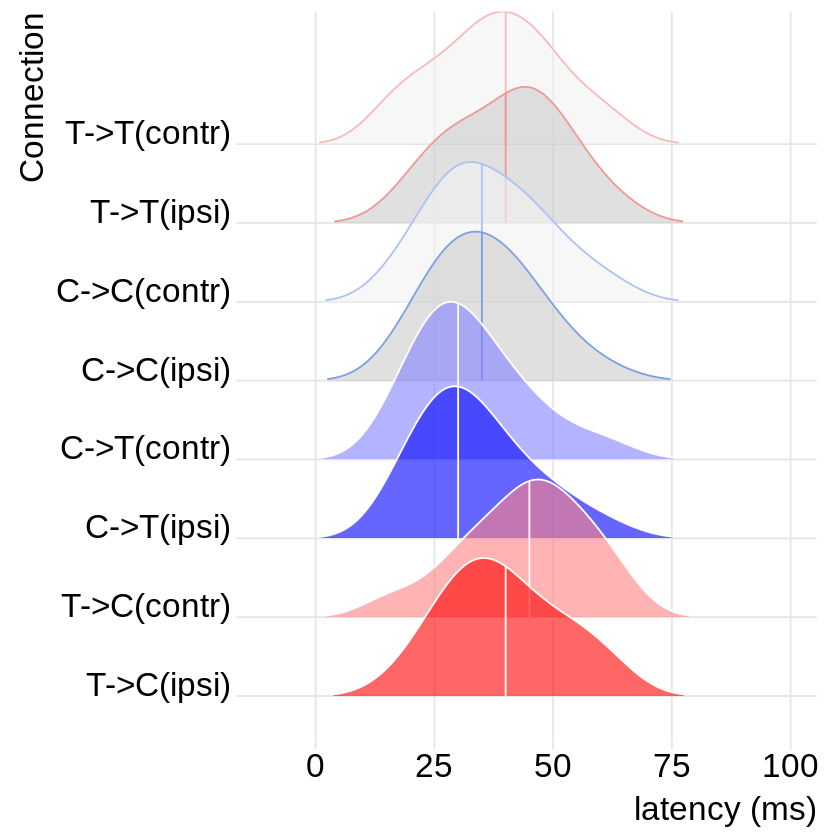

In [406]:

p<-ggplot(d1, aes( y=Connection, x=time_maxCor_clst1, fill = Connection )) +
    geom_density_ridges(aes(color=Connection),
                        quantile_lines = TRUE, bandwidth = 6,
                        quantiles = 2, alpha=0.6,
                        scale = 2, rel_min_height = 0.01)+
scale_fill_manual( values = c("#ff0000", "#ff8080","#0000ff", "#8080ff",  "#cccccc","#f2f2f2", "#cccccc","#f2f2f2"))+
scale_color_manual( values = c("#FFFFFF","#FFFFFF","#FFFFFF","#FFFFFF", "#7aa0e2", "#abc2f2","#ef9797", "#f7b9b9"))+
  theme_ridges() + labs(y = 'Connection', x= "latency (ms)") + xlim(-10,100)+
  theme(legend.position = "none", text=element_text(size=20),
         axis.text=element_text(size=20))

p
# save plot
nF = 1
fname <- sprintf('feature%d_latency_density_ridges.png', nF)
outDir <- paste0(figpath, '/R_stats')
figname<-sprintf('%s/%s', outDir, fname)
png(figname,
    width     = 10,
    height    = 4,
    units     = "in",
    res       = 300,
    pointsize = 4)
print(p)
dev.off()

Warning message:
“Removed 18 rows containing non-finite values (`stat_density_ridges()`).”
Warning message:
“Removed 18 rows containing non-finite values (`stat_density_ridges()`).”


png 
  2

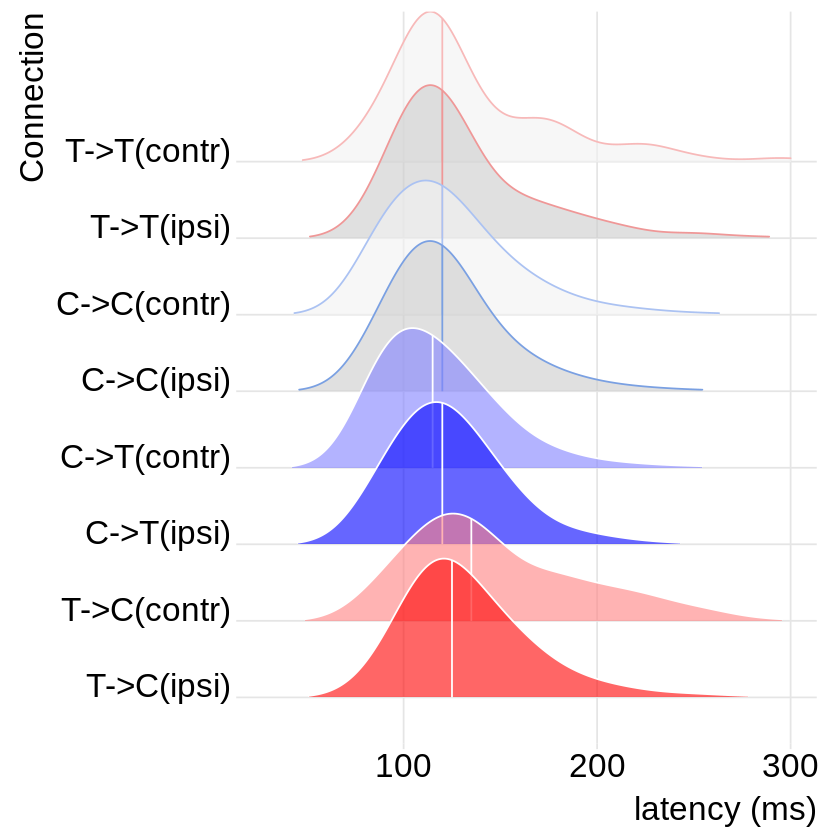

In [466]:

p<-ggplot(d2, aes( y=Connection, x=time_maxCor_clst2, fill = Connection)) +
    geom_density_ridges(aes(color=Connection),quantile_lines = TRUE, bandwidth = 15,
                        quantiles = 2, alpha=0.6, 
                        scale = 2, rel_min_height = 0.01) +
scale_fill_manual( values = c("#ff0000", "#ff8080","#0000ff", "#8080ff",  "#cccccc","#f2f2f2", "#cccccc","#f2f2f2"))+
scale_color_manual( values = c("#FFFFFF","#FFFFFF","#FFFFFF","#FFFFFF", "#7aa0e2", "#abc2f2","#ef9797", "#f7b9b9"))+
  theme_ridges() + labs(x= "latency (ms)") +  xlim(30,300)+
  theme(legend.position = "none",text=element_text(size=20),
         axis.text=element_text(size=20)) 

p
# save plot
nF = 2
fname <- sprintf('feature%d_latency_density_ridges.png', nF)
outDir <- paste0(figpath, '/R_stats')
figname<-sprintf('%s/%s', outDir, fname)
png(figname,
    width     = 10,
    height    = 4,
    units     = "in",
    res       = 300,
    pointsize = 4)
print(p)
dev.off()

Warning message:
“Removed 2564 rows containing non-finite values (`stat_density_ridges()`).”
Warning message:
“Removed 2564 rows containing non-finite values (`stat_density_ridges()`).”


png 
  2

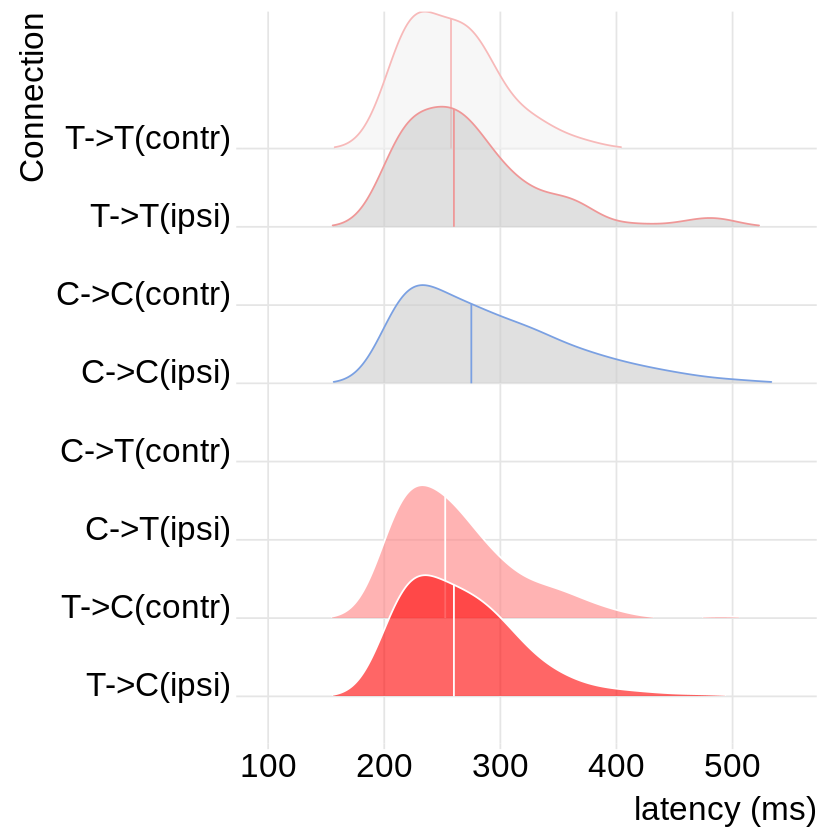

In [435]:

d3_ <- d3
d3_$time_maxCor_clst3[(d3_$Connection != 'C->C(ipsi)') & (d3_$FromRegion=='Cortex')] = NA
p<-ggplot(d3_, aes( y=Connection, x=time_maxCor_clst3, fill = Connection )) +
    geom_density_ridges(aes(color=Connection),
                        quantile_lines = TRUE, bandwidth = 20,
                        quantiles = 2, alpha=0.6, 
                        scale = 1., rel_min_height = 0.01) +
scale_fill_manual( values = c("#ff0000", "#ff8080",  "#cccccc", "#cccccc","#f2f2f2"))+
scale_color_manual( values = c("#FFFFFF","#FFFFFF", "#7aa0e2", "#ef9797", "#f7b9b9"))+
  theme_ridges() + labs(y = 'Connection', x= "latency (ms)") +  xlim(100,550)+
  theme(legend.position = "none",text=element_text(size=20),
          axis.text=element_text(size=20))
       # axis.title.y=element_blank(),
       #  axis.text.y=element_blank(),
       #  axis.ticks.y=element_blank()) 

p
# save plot
nF = 3
fname <- sprintf('feature%d_latency_density_ridges.png', nF)
outDir <- paste0(figpath, '/R_stats')
figname<-sprintf('%s/%s', outDir, fname)
png(figname,
    width     = 10,
    height    = 4,
    units     = "in",
    res       = 300,
    pointsize = 4)
print(p)
dev.off()

#### Comparing THAL/COR F3 ipsilateral and contralateral connections

##### Within-subject comparison

In [338]:
unique(dat$Connection)

[1] "C->C(ipsi)"    "C->C(contr)"   "C->T(contr)"   "C->NA(contr)" 
 [5] "C->T(ipsi)"    "C->NA(ipsi)"   "T->C(ipsi)"    "T->T(ipsi)"   
 [9] "T->NA(ipsi)"   "NA->C(contr)"  "NA->C(ipsi)"   "NA->T(ipsi)"  
[13] "NA->NA(ipsi)"  "T->C(contr)"   "T->NA(contr)"  "NA->NA(contr)"
[17] "T->T(contr)"   "NA->T(contr)"

`summarise()` has grouped output by 'Connection', 'aSubID'. You can override
using the `.groups` argument.
Warning message:
“Removed 25768 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 266 rows containing missing values (`geom_violin()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_pointrange()`).”
Warning message:
“Removed 3 rows containing missing values (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values (`geom_segment()`).”
Warning message:
“Removed 25768 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 266 rows containing missing values (`geom_violin()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_pointrange()`).”
Warning message:
“Removed 3 rows containing missing values (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values (`geom_segment()`).”


png 
  2

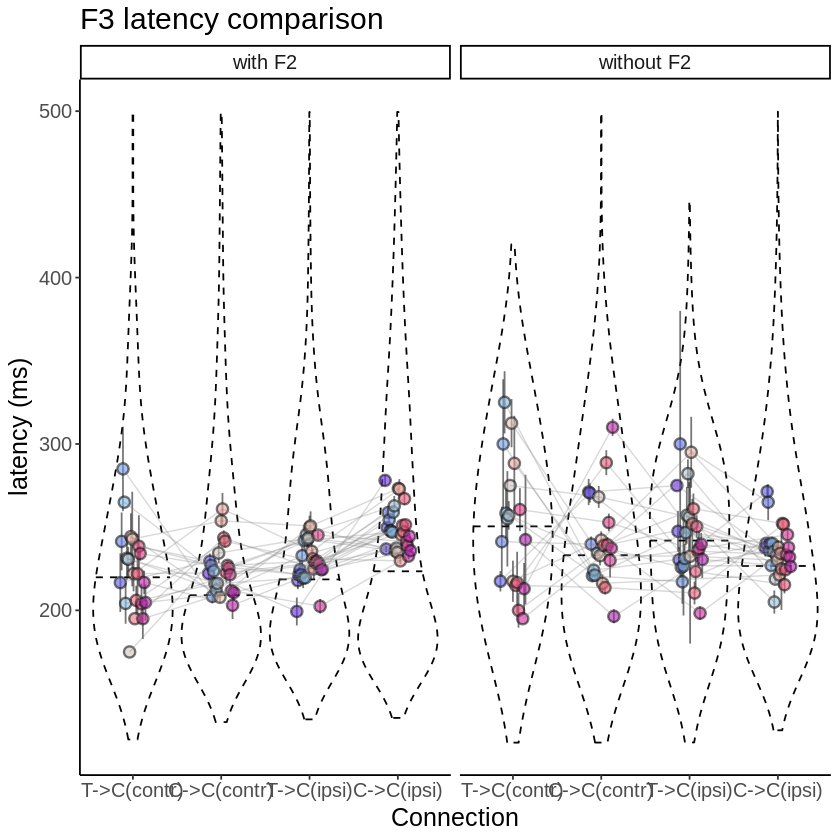

In [237]:
#********** PLOT *************

d_ <- dat_ %>% 
# filter(
#        ((time_maxCor_clst3> 180 & time_maxCor_clst3 < 500) | is.na(time_maxCor_clst3))&
#           (peak_maxCor_clst3>0.5)) %>% 
filter(Connection %in% c('T->C(contr)', 'T->C(ipsi)','C->C(contr)', 'C->C(ipsi)')) %>% 
mutate(elecID = paste(aSubID, stim_chan),feature = time_maxCor_clst3,
       Connection = factor(Connection, levels =c('T->C(contr)', 'C->C(contr)','T->C(ipsi)', 'C->C(ipsi)')))

d_1 <-d_ %>% filter(#(peak_maxCor_clst1>0.4 | is.na(peak_maxCor_clst1)) &
                    (peak_maxCor_clst2>0.5) ) %>% mutate(divide = 'with F2')
d_2 <-d_ %>% filter(#(peak_maxCor_clst1<=0.4 | is.na(peak_maxCor_clst1)) & 
                    (peak_maxCor_clst2<=0.5 | is.na(peak_maxCor_clst2)))%>% mutate(divide = 'without F2')

d__ <- rbind(d_1, d_2)
d_mean <- d__ %>%
  group_by(Connection, aSubID, divide) %>%
  summarize(average = mean(feature,  na.rm=TRUE),
            sd = sd(feature, na.rm=TRUE), 
            n = n(),se = sd / sqrt(n)) %>% ungroup()

nsample <- length(unique(d_mean$aSubID))#dim(dTH_mean)[1]


if (nsample < 20){
dodge = nsample * (1.5/120)  } else if(nsample < 60){
dodge = nsample * (1/120)} else if ( nsample < 120){
    dodge = nsample * (0.45/120)} else{
      dodge = 0.5}
 #plot
dodge=0.3
# plot parameters
cpal<-my_palettes('imperfectSpectral2', nsample, type = 'continuous')    

ttl <- 'F3 latency comparison'

    # if (jplabel %in% c('INS', 'HPC', 'LFC')){ textLiftPar = 2}
p<- ggplot(d__, mapping = aes(Connection, feature)) +
geom_violin(color = "black", trim = FALSE,scale = "width",
              draw_quantiles = c(0.5), linetype='dashed', adjust=2)+
  geom_pointrange(data = d_mean,
             mapping = aes(x= Connection, y = average, fill = aSubID, ymin = average-se, ymax = average+se),
             linewidth=0.5, fatten = 5, shape=21, alpha = 0.6, color = 'grey10',
             position=position_dodge(width=dodge ))+

  geom_line(data = d_mean,
            mapping = aes(x = Connection, y = average, group = aSubID),
            alpha = 0.3, color = 'grey50',
            position=position_dodge(width=dodge ), linewidth= 0.4)+
  facet_wrap(~ divide, nrow=1) +
  # geom_point(aes(color=aSubID),
  #             position=position_dodge(width=dodge), size=0.01, alpha=0.1) +
    scale_fill_manual(values=rev(cpal))+
    scale_color_manual(values=rev(cpal))+ 
    labs(y= "latency (ms)") + 
 scale_y_continuous(limits = c(120,500)) +
  ggtitle(ttl)+
  theme_classic() +
  theme(legend.position="none",
       text = element_text(size=15))

print(p)

# save plot
nF = 3
fname <- sprintf('feature%d_latency_TCipsiVScontr_withinaSubID_dividedbyF2_imperfectSpectral2.png', nF)
outDir <- paste0(figpath, '/R_stats')
figname<-sprintf('%s/%s', outDir, fname)
png(figname,
    width     = 8,
    height    = 5.5,
    units     = "in",
    res       = 300,
    pointsize = 4)
print(p)
dev.off()

In [255]:
colnames(dat_)

[1] "subject"           "aSubID"            "block_name"       
 [4] "stim_chan"         "record_chan"       "sc1"              
 [7] "sc2"               "rc1"               "rc2"              
[10] "stim_shank"        "activated"         "min_pk_time"      
[13] "prom_pk_time"      "num_pks"           "osc_speed"        
[16] "reject_trials_1"   "reject_trials_2"   "reject_trials_3"  
[19] "reject_trials_4"   "reject_trials_5"   "reject_trials_6"  
[22] "CECS"              "CECS_activation"   "record_hot"       
[25] "stim_hot"          "JP_label_out1"     "JP_label_out2"    
[28] "JP_label_in1"      "JP_label_in2"      "Yeo7_out1"        
[31] "Yeo7_out2"         "Yeo7_in1"          "Yeo7_in2"         
[34] "MNIout_coord_1"    "MNIout_coord_2"    "MNIout_coord_3"   
[37] "MNIin_coord_1"     "MNIin_coord_2"     "MNIin_coord_3"    
[40] "LEPTOout_coord_1"  "LEPTOout_coord_2"  "LEPTOout_coord_3" 
[43] "LEPTOin_coord_1"   "LEPTOin_coord_2"   "LEPTOin_coord_3"  
[46] "NATIVEout_coord_1" "NATIVEout_coord_2" "NATIVEout_coord_3"
[49] "NATIVEin_coord_1"  "NATIVEin_coord_2"  "NATIVEin_coord_3" 
[52] "eudDist"           "JP_label_out"      "JP_label_in"      
[55] "sCrossBorder"      "rCrossBorder"      "activated_default"
[58] "activated_SimRule" "pks_time_1"        "pks_time_2"       
[61] "pks_time_3"        "pks_time_4"        "pks_time_5"       
[64] "pks_time_6"        "pks_time_7"        "pks_time_8"       
[67] "pks_time_9"        "pks_time_10"       "pks_time_11"      
[70] "pks_time_12"       "umapAct"           "time_maxCor_clst1"
[73] "peak_maxCor_clst1" "time_maxCor_clst2" "peak_maxCor_clst2"
[76] "time_maxCor_clst3" "peak_maxCor_clst3" "FSout_coord_1"    
[79] "FSout_coord_2"     "FSout_coord_3"     "FSin_coord_1"     
[82] "FSin_coord_2"      "FSin_coord_3"      "xHEMI_code"       
[85] "xHEMI"             "Region"            "FromRegion"       
[88] "ToRegion"          "stimElecID"        "recordElecID"     
[91] "stimArea"          "recordArea"        "xHEMI_short"      
[94] "FromRegion_short"  "ToRegion_short"    "Connection"

`summarise()` has grouped output by 'Connection2', 'connAreas'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'Connection2'. You can override using the
`.groups` argument.
Warning message:
“Removed 305 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 84 rows containing missing values (`geom_violin()`).”
Warning message:
“Removed 3 rows containing missing values (`geom_segment()`).”
Warning message:
“Removed 305 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 84 rows containing missing values (`geom_violin()`).”
Warning message:
“Removed 3 rows containing missing values (`geom_segment()`).”


png 
  2

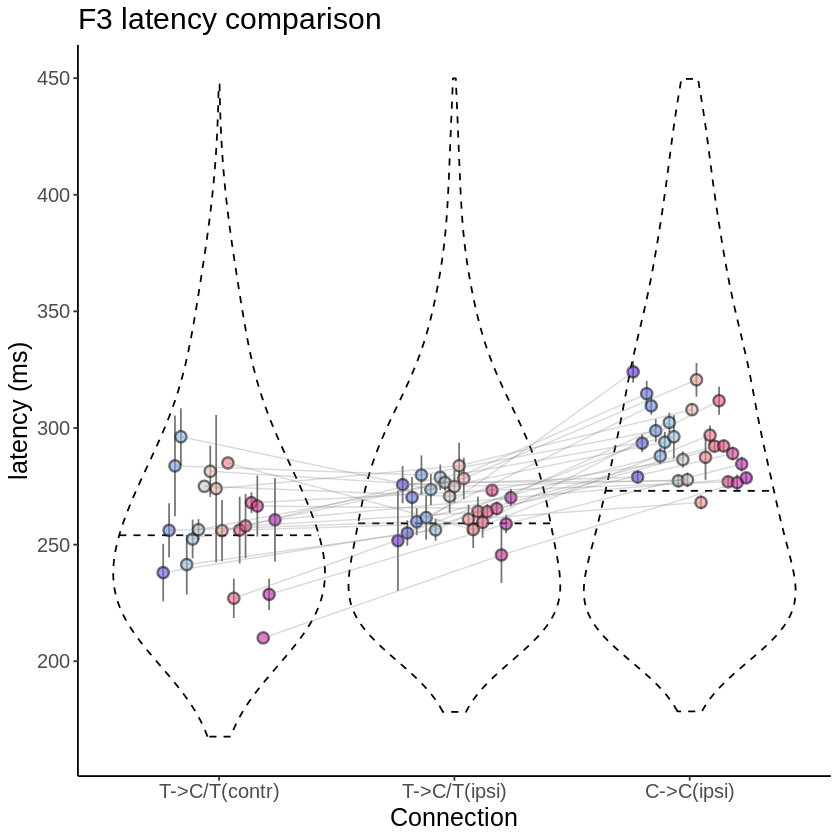

In [441]:
#********** PLOT *************


d_ <- d3 %>%  mutate(Connection2 = case_when(
    FromRegion == 'Thalamus' & xHEMI == 'ipsilateral' ~ 'T->C/T(ipsi)',
    FromRegion == 'Thalamus' & xHEMI == 'contralateral' ~ 'T->C/T(contr)',
    FromRegion == 'Cortex' & ToRegion == 'Cortex'& xHEMI == 'ipsilateral' ~ 'C->C(ipsi)'
), Connection2 = factor(Connection2, levels = c('T->C/T(contr)','T->C/T(ipsi)','C->C(ipsi)')))%>% 
filter(Connection %in% c('T->C(contr)', 'T->C(ipsi)','T->T(contr)', 'T->T(ipsi)', 'C->C(ipsi)')) %>% 
mutate(elecID = paste(aSubID, stim_chan),
       feature = time_maxCor_clst3, 
       FromRegion = factor(FromRegion, levels =c('Thalamus','Cortex'))) %>% 
mutate(connAreas = paste0(JP_label_out,'->', JP_label_in), lataency=feature)


d3_grouped <- d_ %>%
  group_by(Connection2, connAreas, aSubID) %>%
  summarize(median_lat = median(latency, na.rm=TRUE),
            feature= mean(latency,  na.rm=TRUE),
            sd_lat = sd(latency, na.rm=TRUE), 
            n = n(),se = sd_lat / sqrt(n)) %>% ungroup()



d_mean <- d_ %>%
  group_by(Connection2, aSubID) %>%
  summarize(average = mean(feature,  na.rm=TRUE),
            sd = sd(feature, na.rm=TRUE), 
            n = n(),se = sd / sqrt(n)) %>% ungroup()

    nsample <- length(unique(d_mean$aSubID))#dim(dTH_mean)[1]


if (nsample < 20){
dodge = nsample * (1.5/120)  } else if(nsample < 60){
dodge = nsample * (1/120)} else if ( nsample < 120){
    dodge = nsample * (0.45/120)} else{
      dodge = 0.5}
 #plot
dodge=0.5
# plot parameters
cpal<-my_palettes('imperfectSpectral2', nsample, type = 'continuous')    

ttl <- 'F3 latency comparison'

    # if (jplabel %in% c('INS', 'HPC', 'LFC')){ textLiftPar = 2}
p<- ggplot(d_, mapping = aes(Connection2, feature)) +
geom_violin(color = "black", trim = FALSE,scale = "width",
              draw_quantiles = c(0.5), linetype='dashed', adjust=2)+
  geom_pointrange(data = d_mean,
             mapping = aes(x= Connection2, y = average, fill = aSubID, ymin = average-se, ymax = average+se),
             linewidth=0.5, fatten = 5, shape=21, alpha = 0.6, color = 'grey10',
             position=position_dodge(width=dodge ))+

  geom_line(data = d_mean,
            mapping = aes(x = Connection2, y = average, group = aSubID),
            alpha = 0.3, color = 'grey50',
            position=position_dodge(width=dodge ), linewidth= 0.4)+
   labs(x='Connection')+
  # geom_point(aes(color=aSubID),
     #         position=position_dodge(width=dodge), size=0.01, alpha=0.1) +
    scale_fill_manual(values=rev(cpal))+
    scale_color_manual(values=rev(cpal))+ 
    labs(y= "latency (ms)") + 
 scale_y_continuous(limits = c(165,450)) +
  ggtitle(ttl)+
  theme_classic() +
  theme(legend.position="none",
       text = element_text(size=15))

print(p)

# save plot
nF = 3
fname <- sprintf('feature%d_latency_ThalVScor_withinaSubID_imperfectSpectral2_3groups_new.png', nF)
outDir <- paste0(figpath, '/R_stats')
figname<-sprintf('%s/%s', outDir, fname)
png(figname,
    width     = 4.5,
    height    = 5.5,
    units     = "in",
    res       = 300,
    pointsize = 4)
print(p)
dev.off()

`summarise()` has grouped output by 'xHEMI'. You can override using the
`.groups` argument.
Warning message:
“Removed 1 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 3 rows containing missing values (`geom_violin()`).”
Warning message:
“Removed 28 rows containing missing values (`geom_segment()`).”
Warning message:
“Removed 1 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 1 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 3 rows containing missing values (`geom_violin()`).”
Warning message:
“Removed 28 rows containing missing values (`geom_segment()`).”
Warning message:
“Removed 1 rows containing missing values (`geom_point()`).”


png 
  2

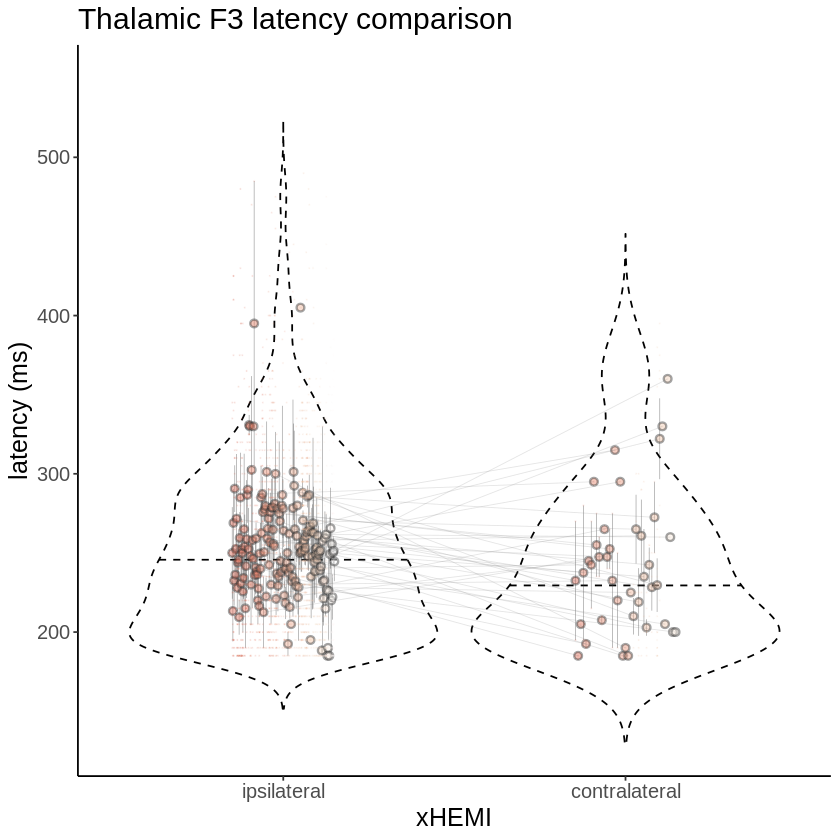

In [244]:
#********** PLOT *************

d_ <- dat %>% 
filter(((time_maxCor_clst1> 10 & time_maxCor_clst1 < 60) | is.na(time_maxCor_clst1)) &
       ((time_maxCor_clst2> 50 & time_maxCor_clst2 < 185) | is.na(time_maxCor_clst2))&
       ((time_maxCor_clst3> 180 & time_maxCor_clst3 < 500) | is.na(time_maxCor_clst3))&
       ((peak_maxCor_clst1>0.4|is.na(peak_maxCor_clst1))& 
        (peak_maxCor_clst2>0.5|is.na(peak_maxCor_clst2)) & 
        (peak_maxCor_clst3>0.5|is.na(peak_maxCor_clst3)))) %>% 
filter(FromRegion == 'Thalamus' & !(JP_label_in %in% c('antTH', 'midTH', 'pstTH'))) %>% 
mutate(elecID = paste(aSubID, stim_chan),feature = time_maxCor_clst3)

d_mean <- d_ %>%
  group_by(xHEMI, elecID) %>%
  summarize(average = mean(feature,  na.rm=TRUE),
            sd = sd(feature, na.rm=TRUE), 
            n = n(),se = sd / sqrt(n)) %>% ungroup()

    nsample <- length(unique(d_mean$elecID))#dim(dTH_mean)[1]


if (nsample < 20){
dodge = nsample * (1.5/120)  } else if(nsample < 60){
dodge = nsample * (1/120)} else if ( nsample < 120){
    dodge = nsample * (0.45/120)} else{
      dodge = 0.5}
 #plot
dodge=0.3
# plot parameters
cpal<-my_palettes('rosy', nsample, type = 'continuous')    

ttl <- 'Thalamic F3 latency comparison'

    # if (jplabel %in% c('INS', 'HPC', 'LFC')){ textLiftPar = 2}
p<- ggplot(d_, mapping = aes(xHEMI, feature)) +

geom_violin(color = "black", trim = FALSE,scale = "width",
              draw_quantiles = c(0.5), linetype='dashed')+

  geom_pointrange(data = d_mean,
             mapping = aes(x= xHEMI, y = average, fill = elecID, ymin = average-se, ymax = average+se),
             linewidth=0.2, fatten = 3, shape=21, alpha = 0.45, color = 'grey20',
             position=position_dodge(width=dodge ))+

  geom_line(data = d_mean,
            mapping = aes(x = xHEMI, y = average, group = elecID),
            alpha = 0.2, color = 'grey50',
            position=position_dodge(width=dodge ), linewidth= 0.25)+

 geom_point(aes(color=elecID),
             position=position_dodge(width=dodge), size=0.01, alpha=0.1) +
 scale_fill_manual(values=cpal)+
    scale_color_manual(values=cpal)+ #+ scale_fill_brewer(palette = "Spectral")
    labs(y= "latency (ms)") + 
 scale_y_continuous(limits = c(130,550)) +
  ggtitle(ttl)+
  theme_classic() +
  theme(legend.position="none",
       text = element_text(size=15))

print(p)

# save plot
nF = 3
fname <- sprintf('feature%d_latency_THALipsiVScontr_withinElec_rosy.png', nF)
outDir <- paste0(figpath, '/R_stats')
figname<-sprintf('%s/%s', outDir, fname)
png(figname,
    width     = 4.5,
    height    = 5,
    units     = "in",
    res       = 300,
    pointsize = 4)
print(p)
dev.off()

`summarise()` has grouped output by 'xHEMI'. You can override using the
`.groups` argument.
Warning message:
“Removed 1341 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 104 rows containing missing values (`geom_pointrange()`).”
Warning message:
“Removed 363 rows containing missing values (`geom_segment()`).”
Warning message:
“Removed 104 rows containing missing values (`geom_line()`).”
Warning message:
“Removed 1341 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 1341 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 104 rows containing missing values (`geom_pointrange()`).”
Warning message:
“Removed 363 rows containing missing values (`geom_segment()`).”
Warning message:
“Removed 104 rows containing missing values (`geom_line()`).”
Warning message:
“Removed 1341 rows containing missing values (`geom_point()`).”


png 
  2

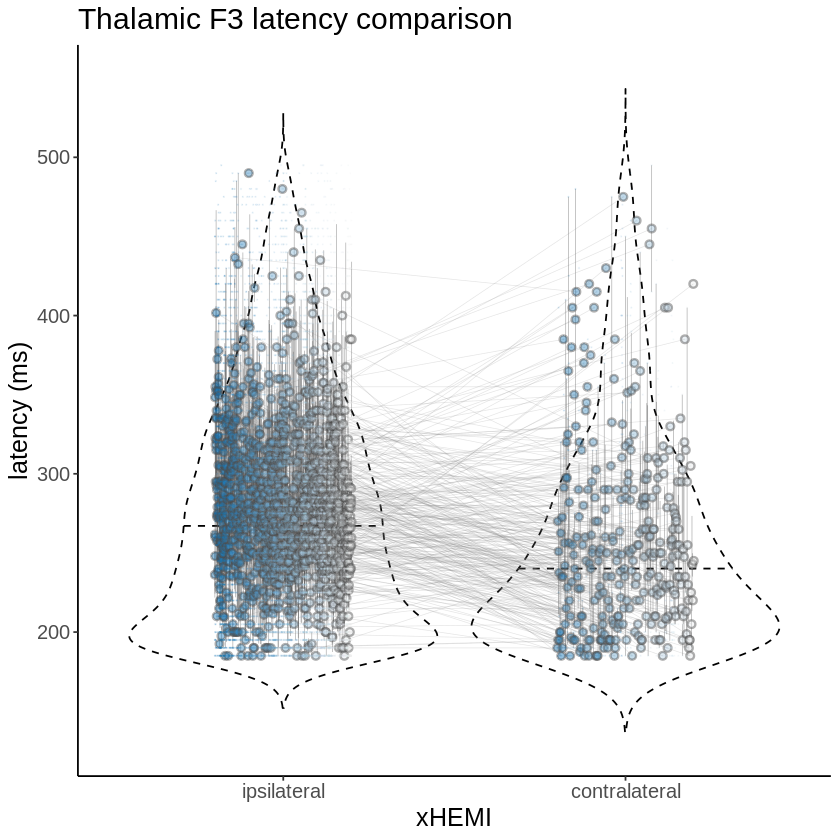

In [272]:
#********** PLOT *************

d_ <- dat %>% 
filter(((time_maxCor_clst1> 10 & time_maxCor_clst1 < 60) | is.na(time_maxCor_clst1)) &
       ((time_maxCor_clst2> 50 & time_maxCor_clst2 < 185) | is.na(time_maxCor_clst2))&
       ((time_maxCor_clst3> 180 & time_maxCor_clst3 < 500) | is.na(time_maxCor_clst3))&
       ((peak_maxCor_clst1>0.4|is.na(peak_maxCor_clst1))& 
        (peak_maxCor_clst2>0.5|is.na(peak_maxCor_clst2)) & 
        (peak_maxCor_clst3>0.5|is.na(peak_maxCor_clst3)))) %>% 
filter(FromRegion == 'Cortex' & !(JP_label_in %in% c('antTH', 'midTH', 'pstTH'))) %>% 
mutate(elecID = paste(aSubID, stim_chan),feature = time_maxCor_clst3)

d_mean <- d_ %>%
  group_by(xHEMI, elecID) %>%
  summarize(average = mean(feature,  na.rm=TRUE),
            sd = sd(feature, na.rm=TRUE), 
            n = n(),se = sd / sqrt(n)) %>% ungroup()

    nsample <- length(unique(d_mean$elecID))#dim(dTH_mean)[1]


if (nsample < 20){
dodge = nsample * (1.5/120)  } else if(nsample < 60){
dodge = nsample * (1/120)} else if ( nsample < 120){
    dodge = nsample * (0.45/120)} else{
      dodge = 0.4}
 #plot
#dodge=0.3
# plot parameters
cpal<-my_palettes('blue', nsample, type = 'continuous')    

ttl <- 'Thalamic F3 latency comparison'

    # if (jplabel %in% c('INS', 'HPC', 'LFC')){ textLiftPar = 2}
p<- ggplot(d_, mapping = aes(xHEMI, feature)) +

  geom_violin(color = "black", trim = FALSE,scale = "width",
              draw_quantiles = c(0.5), linetype='dashed')+
  geom_pointrange(data = d_mean,
             mapping = aes(x= xHEMI, y = average, fill = elecID, ymin = average-se, ymax = average+se),
             linewidth=0.2, fatten = 3, shape=21, alpha = 0.45, color = "grey30",
             position=position_dodge(width=dodge ))+

  geom_line(data = d_mean,
            mapping = aes(x = xHEMI, y = average, group = elecID),
            alpha = 0.2, color = 'grey50',
            position=position_dodge(width=dodge ), linewidth= 0.2)+

 geom_point(aes(color=elecID),
             position=position_dodge(width=dodge), size=0.01, alpha=0.1) +
    scale_fill_manual(values=rev(cpal))+
    scale_color_manual(values=rev(cpal))+ 
    labs(y= "latency (ms)") + 
 scale_y_continuous(limits = c(130,550)) +
  ggtitle(ttl)+
  theme_classic() +
  theme(legend.position="none",
       text = element_text(size=15))

print(p)

# save plot
nF=3
fname <- sprintf('feature%d_latency_CORipsiVScontr_withinElec_blue.png', nF)
outDir <- paste0(figpath, '/R_stats')
figname<-sprintf('%s/%s', outDir, fname)
png(figname,
    width     = 4.5,
    height    = 5,
    units     = "in",
    res       = 300,
    pointsize = 4)
print(p)
dev.off()

### Compare ipsi vs contra C-T, C-C F2

`summarise()` has grouped output by 'Connection', 'connAreas'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'Connection'. You can override using the
`.groups` argument.
Warning message:
“Removed 2 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 145 rows containing missing values (`geom_violin()`).”
Warning message:
“Removed 1 rows containing missing values (`geom_segment()`).”


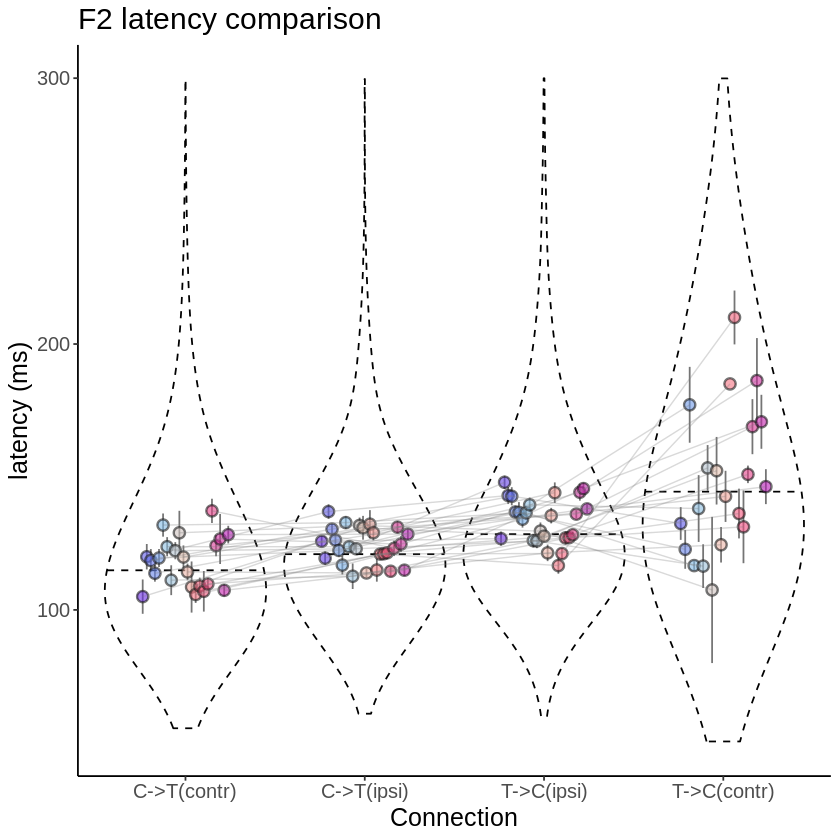

In [467]:
#********** PLOT *************

d_ <- d2 %>% 
filter(
      Connection %in% c('C->T(contr)', 'C->T(ipsi)', 'T->C(contr)','T->C(ipsi)') )%>% 
mutate(elecID = paste(aSubID, stim_chan),
       feature = time_maxCor_clst2, 
      Connection=factor(Connection, 
                        levels=c('C->T(contr)', 'C->T(ipsi)','T->C(ipsi)','T->C(contr)') ))%>% 
mutate(connAreas = paste0(JP_label_out,'->', JP_label_in), latency=feature)



d2_grouped <- d_ %>%
  group_by(Connection, connAreas, aSubID) %>%
  summarize(median_lat = median(latency, na.rm=TRUE),
            feature= mean(latency,  na.rm=TRUE),
            sd_lat = sd(latency, na.rm=TRUE), 
            n = n(),se = sd_lat / sqrt(n)) %>% ungroup()



d_mean <- d_ %>%
  group_by(Connection, aSubID) %>%
  summarize(average = mean(feature,  na.rm=TRUE),
            sd = sd(feature, na.rm=TRUE), 
            n = n(),se = sd / sqrt(n)) %>% ungroup()

    nsample <- length(unique(d_mean$aSubID))#dim(dTH_mean)[1]



if (nsample < 20){
dodge = nsample * (1.5/120)  } else if(nsample < 60){
dodge = nsample * (1/120)} else if ( nsample < 120){
    dodge = nsample * (0.45/120)} else{
      dodge = 0.4}
 #plot
dodge=0.5
# plot parameters
cpal<-my_palettes('imperfectSpectral2', nsample, type = 'continuous')    

ttl <- 'F2 latency comparison'

    # if (jplabel %in% c('INS', 'HPC', 'LFC')){ textLiftPar = 2}
p<- ggplot(d_, mapping = aes(Connection, feature)) +

  geom_violin(color = "black", trim = FALSE,scale = "width",
              draw_quantiles = c(0.5), linetype='dashed', adjust=3)+
  geom_pointrange(data = d_mean,
             mapping = aes(x= Connection, y = average, fill = aSubID, ymin = average-se, ymax = average+se),
             linewidth=0.5, fatten = 5, shape=21, alpha = 0.6, color = 'grey10',
             position=position_dodge(width=dodge ))+

  geom_line(data = d_mean,
            mapping = aes(x = Connection, y = average, group = aSubID),
            alpha = 0.3, color = 'grey50',
            position=position_dodge(width=dodge ), linewidth= 0.4)+

  # geom_point(aes(color=aSubID),
  #             position=position_dodge(width=dodge), size=0.01, alpha=0.1) +
    scale_fill_manual(values=rev(cpal))+
    scale_color_manual(values=rev(cpal))+ 
    labs(y= "latency (ms)") + 
 scale_y_continuous(limits = c(50,300)) +
  ggtitle(ttl)+
  theme_classic() +
  theme(legend.position="none",
       text = element_text(size=15))

print(p)

# save plot
# nF=2
# fname <- sprintf('feature%d_latency_ipsivscontraCTTC_withinaSubID_imperfectSpectral2.png', nF)
# outDir <- paste0(figpath, '/R_stats')
# figname<-sprintf('%s/%s', outDir, fname)
# png(figname,
#     width     = 6,
#     height    = 5.5,
#     units     = "in",
#     res       = 300,
#     pointsize = 4)
# print(p)
# dev.off()

### Compare CT vs CC, ipsilateral and contralateral, F1

`summarise()` has grouped output by 'Connection', 'connAreas'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'Connection'. You can override using the
`.groups` argument.
Warning message:
“Removed 2243 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 293 rows containing missing values (`geom_violin()`).”
Warning message:
“Removed 4 rows containing missing values (`geom_segment()`).”
Warning message:
“Removed 2243 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 293 rows containing missing values (`geom_violin()`).”
Warning message:
“Removed 4 rows containing missing values (`geom_segment()`).”


png 
  2

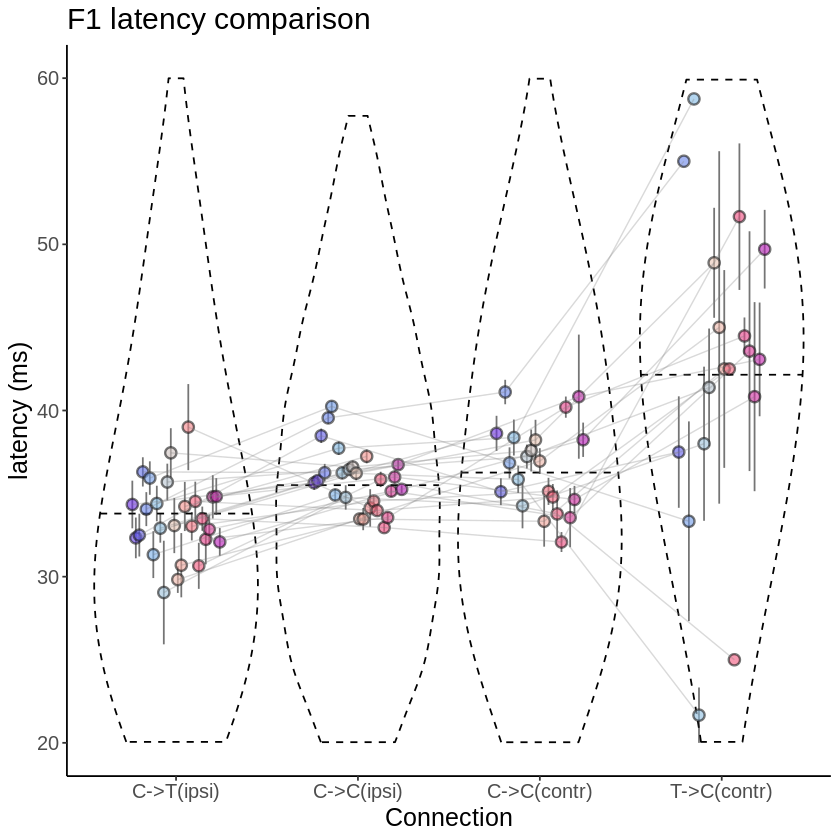

In [415]:
#********** PLOT *************

d_ <- d1 %>% 
filter(
      Connection %in% c('C->C(ipsi)', 'C->T(ipsi)','C->C(contr)','T->C(contr)') )%>% 
mutate(elecID = paste(aSubID, stim_chan),
       feature = time_maxCor_clst1, 
      Connection=factor(Connection, 
                        levels=c('C->T(ipsi)','C->C(ipsi)', 'C->C(contr)','T->C(contr)') ))%>% 
mutate(connAreas = paste0(JP_label_out,'->', JP_label_in), latency=feature)



d1_grouped <- d_ %>%
  group_by(Connection, connAreas, aSubID) %>%
  summarize(median_lat = median(latency, na.rm=TRUE),
            feature= mean(latency,  na.rm=TRUE),
            sd_lat = sd(latency, na.rm=TRUE), 
            n = n(),se = sd_lat / sqrt(n)) %>% ungroup()



d_mean <- d_ %>%
  group_by(Connection, aSubID) %>%
  summarize(average = mean(feature,  na.rm=TRUE),
            sd = sd(feature, na.rm=TRUE), 
            n = n(),se = sd / sqrt(n)) %>% ungroup()

    nsample <- length(unique(d_mean$aSubID))#dim(dTH_mean)[1]



if (nsample < 20){
dodge = nsample * (1.5/120)  } else if(nsample < 60){
dodge = nsample * (1/120)} else if ( nsample < 120){
    dodge = nsample * (0.45/120)} else{
      dodge = 0.4}
 #plot
dodge=0.5
# plot parameters
cpal<-my_palettes('imperfectSpectral2', nsample, type = 'continuous')    

ttl <- 'F1 latency comparison'

    # if (jplabel %in% c('INS', 'HPC', 'LFC')){ textLiftPar = 2}
p<- ggplot(d_, mapping = aes(Connection, feature)) +

  geom_violin(color = "black", trim = FALSE,scale = "width",
              draw_quantiles = c(0.5), linetype='dashed', adjust=3)+
  geom_pointrange(data = d_mean,
             mapping = aes(x= Connection, y = average, fill = aSubID, ymin = average-se, ymax = average+se),
             linewidth=0.5, fatten = 5, shape=21, alpha = 0.6, color = 'grey10',
             position=position_dodge(width=dodge ))+

  geom_line(data = d_mean,
            mapping = aes(x = Connection, y = average, group = aSubID),
            alpha = 0.3, color = 'grey50',
            position=position_dodge(width=dodge ), linewidth= 0.4)+

  # geom_point(aes(color=aSubID),
  #             position=position_dodge(width=dodge), size=0.01, alpha=0.1) +
    scale_fill_manual(values=rev(cpal))+
    scale_color_manual(values=rev(cpal))+ 
    labs(y= "latency (ms)") + 
 scale_y_continuous(limits = c(20,60)) +
  ggtitle(ttl)+
  theme_classic() +
  theme(legend.position="none",
       text = element_text(size=15))

print(p)

# save plot
nF=1
fname <- sprintf('feature%d_latency_CCvsCTbi_withinaSubID_imperfectSpectral2.png', nF)
outDir <- paste0(figpath, '/R_stats')
figname<-sprintf('%s/%s', outDir, fname)
png(figname,
    width     = 6,
    height    = 5.5,
    units     = "in",
    res       = 300,
    pointsize = 4)
print(p)
dev.off()

### Compare CT vs CC, TC vs TT, ipsilateral, F1 latency

`summarise()` has grouped output by 'Connection', 'connAreas'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'Connection'. You can override using the
`.groups` argument.
Warning message:
“Removed 2276 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 309 rows containing missing values (`geom_violin()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_segment()`).”
Warning message:
“Removed 2276 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 309 rows containing missing values (`geom_violin()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_segment()`).”


png 
  2

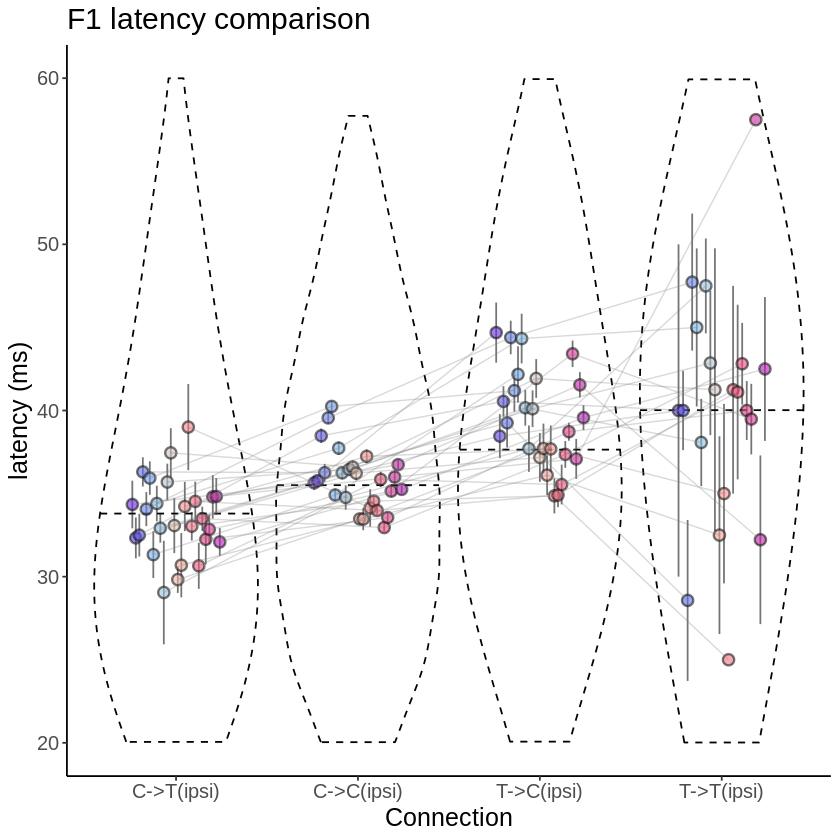

In [357]:
#********** PLOT *************

d_ <- d1 %>% 
filter(xHEMI == 'ipsilateral' & 
      Connection %in% c('C->C(ipsi)', 'C->T(ipsi)','T->C(ipsi)','T->T(ipsi)') )%>% 
mutate(elecID = paste(aSubID, stim_chan),
       feature = time_maxCor_clst1, 
      Connection=factor(Connection, 
                        levels=c('C->T(ipsi)','C->C(ipsi)', 'T->C(ipsi)','T->T(ipsi)') ))%>% 
mutate(connAreas = paste0(JP_label_out,'->', JP_label_in), latency=feature)



d1_grouped <- d_ %>%
  group_by(Connection, connAreas, aSubID) %>%
  summarize(median_lat = median(latency, na.rm=TRUE),
            feature= mean(latency,  na.rm=TRUE),
            sd_lat = sd(latency, na.rm=TRUE), 
            n = n(),se = sd_lat / sqrt(n)) %>% ungroup()



d_mean <- d_ %>%
  group_by(Connection, aSubID) %>%
  summarize(average = mean(feature,  na.rm=TRUE),
            sd = sd(feature, na.rm=TRUE), 
            n = n(),se = sd / sqrt(n)) %>% ungroup()

    nsample <- length(unique(d_mean$aSubID))#dim(dTH_mean)[1]



if (nsample < 20){
dodge = nsample * (1.5/120)  } else if(nsample < 60){
dodge = nsample * (1/120)} else if ( nsample < 120){
    dodge = nsample * (0.45/120)} else{
      dodge = 0.4}
 #plot
dodge=0.5
# plot parameters
cpal<-my_palettes('imperfectSpectral2', nsample, type = 'continuous')    

ttl <- 'F1 latency comparison'

    # if (jplabel %in% c('INS', 'HPC', 'LFC')){ textLiftPar = 2}
p<- ggplot(d_, mapping = aes(Connection, feature)) +

  geom_violin(color = "black", trim = FALSE,scale = "width",
              draw_quantiles = c(0.5), linetype='dashed', adjust=3)+
  geom_pointrange(data = d_mean,
             mapping = aes(x= Connection, y = average, fill = aSubID, ymin = average-se, ymax = average+se),
             linewidth=0.5, fatten = 5, shape=21, alpha = 0.6, color = 'grey10',
             position=position_dodge(width=dodge ))+

  geom_line(data = d_mean,
            mapping = aes(x = Connection, y = average, group = aSubID),
            alpha = 0.3, color = 'grey50',
            position=position_dodge(width=dodge ), linewidth= 0.4)+

  # geom_point(aes(color=aSubID),
  #             position=position_dodge(width=dodge), size=0.01, alpha=0.1) +
    scale_fill_manual(values=rev(cpal))+
    scale_color_manual(values=rev(cpal))+ 
    labs(y= "latency (ms)") + 
 scale_y_continuous(limits = c(20,60)) +
  ggtitle(ttl)+
  theme_classic() +
  theme(legend.position="none",
       text = element_text(size=15))

print(p)

# save plot
nF=1
fname <- sprintf('feature%d_latency_CCvsCTipsi_withinaSubID_imperfectSpectral2_new.png', nF)
outDir <- paste0(figpath, '/R_stats')
figname<-sprintf('%s/%s', outDir, fname)
png(figname,
    width     = 4.5,
    height    = 5.5,
    units     = "in",
    res       = 300,
    pointsize = 4)
print(p)
dev.off()

## Stats for regional matrix

1. Testing for "The thalamus seems to be the universal receiver of first-order connectivities, as the thalamus (including anterior [antTH], mid- [midTH], and posterior [pstTH] thalamus) has the strongest, earliest, and broadest Feature-1 representation, comparing to the rest of the brain."

feature to test: peak_maxCor_clst1, time_maxCor_clst1

### Testing for peak_maxCor_clst1

In [48]:
# prepare data
vnames = colnames(dat)
peakMat = dat[,grep('pks_time', vnames)]
BrainAreas <- c('BG', 'AMY',  #subcortical, exclude 'CLT'
                'OFC', 'ACC', 'MFC', 'LFC', 'INS',# frontal # exclude 'FP'
                'TP', 'HPC', 'PHG', 'FG', 'ITG', 'MTG', 'STG',#temporal
                'MCC', 'SM', 'SPL', 'IPL', 'PMC', 'OCC', # parietal
                'antTH', 'midTH', 'pstTH')

d <- dat %>% filter(!( # exculsion cases
    rCrossBorder == 1 | sCrossBorder == 1 | eudDist<5 |
    rowSums(peakMat, na.rm=TRUE) < 10)
  ) %>% filter(JP_label_in %in% BrainAreas &
               JP_label_out %in% BrainAreas & umapAct==1)

In [49]:
# threshold and cleanup dataframe for stats
nF = 1
thr = 0.4
featureName <- paste0('peak_maxCor_clst', nF)
d['feature'] = d[featureName]
#clean data frame
variables <- c("subject", "JP_label_in", "JP_label_out", "feature",  "xHEMI", "MNIout_coord_1", "MNIin_coord_1")
cd<- data.frame(matrix(ncol=length(variables),nrow=0,
                       dimnames=list(NULL, variables)))

for (fromArea in BrainAreas){
  for(toArea in BrainAreas){

  d_ <- d %>% filter(JP_label_in == fromArea & JP_label_out==toArea &
                      feature > thr) %>%
    select("subject", "JP_label_in", "JP_label_out", "feature",  "xHEMI", "MNIout_coord_1", "MNIin_coord_1")
  if (dim(d_)[1]>5){
    cd <- rbind(cd, d_)
  }
  }
}

In [50]:
# prepare data
cd_ <- cd %>% filter(!(JP_label_in %in% c('BG', 'AMY')) & !(JP_label_out %in% c('BG', 'AMY')) &
                       MNIin_coord_1!=0 & MNIout_coord_1!=0) %>%  # exclude subcortical areas
  mutate(toRegion = case_when(
    JP_label_in %in% c('antTH', 'pstTH','midTH') ~ 'Thalamus',
    JP_label_in %in% corticalAreas ~ 'Cortex'
  ), toHemisphere = case_when(
    (MNIin_coord_1 < 0) ~ 'l',
    (MNIin_coord_1 > 0) ~ 'r'
  ), fromHemisphere = case_when(
    (MNIout_coord_1 < 0) ~ 'l',
    (MNIout_coord_1 > 0) ~ 'r')
  ) %>% unite('fromAreas', c("JP_label_out","fromHemisphere"), sep='-', remove=FALSE) %>%
  unite('toAreas', c("JP_label_in","toHemisphere"), sep='-', remove=FALSE)

In [57]:
# do stats
print(sprintf('Feature1 representation of conn to thalamus is %.3f', mean(cd_$feature[cd_$toRegion == 'Thalamus'])))
print(sprintf('Feature1 representation of conn to cortex is %.3f', mean(cd_$feature[cd_$toRegion == 'Cortex'])))

alm1 <- lmer(feature ~ toRegion + xHEMI + (1|subject/toAreas) , cd_)
summy <- summary(alm1)
print(summy)

[1] "Feature1 representation of conn to thalamus is 0.633"
[1] "Feature1 representation of conn to cortex is 0.622"
Linear mixed model fit by REML ['lmerMod']
Formula: feature ~ toRegion + xHEMI + (1 | subject/toAreas)
   Data: cd_

REML criterion at convergence: -37000.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.59377 -0.74475  0.07993  0.75906  2.94502 

Random effects:
 Groups          Name        Variance  Std.Dev.
 toAreas:subject (Intercept) 0.0005450 0.02335 
 subject         (Intercept) 0.0002177 0.01476 
 Residual                    0.0111290 0.10549 
Number of obs: 22608, groups:  toAreas:subject, 491; subject, 26

Fixed effects:
                    Estimate Std. Error t value
(Intercept)         0.625730   0.003345 187.064
toRegionThalamus    0.007070   0.003812   1.855
xHEMIcontralateral -0.008959   0.002544  -3.522

Correlation of Fixed Effects:
            (Intr) tRgnTh
toRegnThlms -0.189       
xHEMIcntrlt -0.069 -0.049


In [58]:
alm0 <- lmer(feature ~ xHEMI +(1|subject/toAreas/) , cd_)
aov <- anova(alm0, alm1)
print(aov)

ERROR: Error in parse(text = x, srcfile = src): <text>:1:50: unexpected ')'
1: alm0 <- lmer(feature ~ xHEMI +(1|subject/toAreas/)
                                                     ^


### Testing for time_maxCor_clst1

In [96]:
# threshold and cleanup dataframe for stats
nF = 1
thr = 0.4
featureName <- paste0('time_maxCor_clst', nF)
d['feature'] = d[featureName]
#clean data frame
variables <- c("subject", "JP_label_in", "JP_label_out", "feature",  "xHEMI", "MNIout_coord_1", "MNIin_coord_1")
cd<- data.frame(matrix(ncol=length(variables),nrow=0,
                       dimnames=list(NULL, variables)))

for (fromArea in BrainAreas){
  for(toArea in BrainAreas){

  d_ <- d %>% filter(JP_label_in == fromArea & JP_label_out==toArea &
                      feature > thr) %>%
    select("subject", "JP_label_in", "JP_label_out", "feature",  "xHEMI", "MNIout_coord_1", "MNIin_coord_1")
  if (dim(d_)[1]>5){
    cd <- rbind(cd, d_)
  }
  }
}

In [104]:
head(cd_)

subject,toAreas,JP_label_in,fromAreas,JP_label_out,feature,xHEMI,MNIout_coord_1,MNIin_coord_1,fromRegion,toHemisphere,fromHemisphere
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<fct>,<dbl>,<dbl>,<chr>,<chr>,<chr>
S21_166_TM,OFC-l,OFC,OFC-l,OFC,340,ipsilateral,-17.78949,-7.578193,Cortex,l,l
S21_166_TM,OFC-l,OFC,OFC-l,OFC,425,ipsilateral,-17.78949,-12.656787,Cortex,l,l
S21_166_TM,OFC-l,OFC,OFC-l,OFC,370,ipsilateral,-17.78949,-27.615656,Cortex,l,l
S21_166_TM,OFC-l,OFC,OFC-l,OFC,500,ipsilateral,-17.78949,-32.582501,Cortex,l,l
S21_166_TM,OFC-l,OFC,OFC-l,OFC,430,ipsilateral,-37.76971,-7.578193,Cortex,l,l
S21_166_TM,OFC-l,OFC,OFC-l,OFC,205,ipsilateral,-37.76971,-12.656787,Cortex,l,l


In [97]:
# prepare data
cd_ <- cd %>% filter(!(JP_label_in %in% c('BG', 'AMY')) & !(JP_label_out %in% c('BG', 'AMY')) &
                       MNIin_coord_1!=0 & MNIout_coord_1!=0) %>%  # exclude subcortical areas
  mutate(toRegion = case_when(
    JP_label_in %in% c('antTH', 'pstTH','midTH') ~ 'Thalamus',
    JP_label_in %in% corticalAreas ~ 'Cortex'
  ), toHemisphere = case_when(
    (MNIin_coord_1 < 0) ~ 'l',
    (MNIin_coord_1 > 0) ~ 'r'
  ), fromHemisphere = case_when(
    (MNIout_coord_1 < 0) ~ 'l',
    (MNIout_coord_1 > 0) ~ 'r')
  ) %>% unite('fromAreas', c("JP_label_out","fromHemisphere"), sep='-', remove=FALSE) %>%
  unite('toAreas', c("JP_label_in","toHemisphere"), sep='-', remove=FALSE)

In [98]:
# do stats
print(sprintf('Feature1 representation latency of conn to thalamus is %.3f ms', mean(cd_$feature[cd_$toRegion == 'Thalamus'])))
print(sprintf('Feature1 representation latency of conn to cortex is %.3f ms', mean(cd_$feature[cd_$toRegion == 'Cortex'])))

alm1 <- lmer(feature ~ toRegion + (1|subject/toAreas) , cd_)
summy <- summary(alm1)
print(summy)

[1] "Feature1 representation latency of conn to thalamus is 34.761 ms"
[1] "Feature1 representation latency of conn to cortex is 36.988 ms"
Linear mixed model fit by REML ['lmerMod']
Formula: feature ~ toRegion + (1 | subject/toAreas)
   Data: cd_

REML criterion at convergence: 221945.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9785 -0.6752 -0.0640  0.5553 13.1664 

Random effects:
 Groups          Name        Variance Std.Dev.
 toAreas:subject (Intercept)   6.184   2.487  
 subject         (Intercept)   1.561   1.249  
 Residual                    175.195  13.236  
Number of obs: 27672, groups:  toAreas:subject, 494; subject, 26

Fixed effects:
                 Estimate Std. Error t value
(Intercept)       37.2551     0.3032 122.860
toRegionThalamus  -2.6791     0.4224  -6.343

Correlation of Fixed Effects:
            (Intr)
toRegnThlms -0.224


In [99]:
alm0 <- lmer(feature ~ (1|subject/toAreas) , cd_)
aov <- anova(alm0, alm1)
print(aov)

refitting model(s) with ML (instead of REML)



Data: cd_
Models:
alm0: feature ~ (1 | subject/toAreas)
alm1: feature ~ toRegion + (1 | subject/toAreas)
     npar    AIC    BIC  logLik deviance  Chisq Df Pr(>Chisq)    
alm0    4 221992 222025 -110992   221984                         
alm1    5 221955 221996 -110972   221945 38.919  1  4.417e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


2. "The thalamus feedback to the whole brain in ~200 ms of its stimulation. Having the Feature 3 generally earlier than the non-thalamus areas (stats here)"

In [100]:
# threshold and cleanup dataframe for stats
nF = 3
thr = 0.5
featureName <- paste0('time_maxCor_clst', nF)
d['feature'] = d[featureName]
#clean data frame
variables <- c("subject", "JP_label_in", "JP_label_out", "feature",  "xHEMI", "MNIout_coord_1", "MNIin_coord_1")
cd<- data.frame(matrix(ncol=length(variables),nrow=0,
                       dimnames=list(NULL, variables)))

for (fromArea in BrainAreas){
  for(toArea in BrainAreas){

  d_ <- d %>% filter(JP_label_in == fromArea & JP_label_out==toArea &
                      feature > thr) %>%
    select("subject", "JP_label_in", "JP_label_out", "feature",  "xHEMI", "MNIout_coord_1", "MNIin_coord_1")
  if (dim(d_)[1]>5){
    cd <- rbind(cd, d_)
  }
  }
}

In [101]:
# prepare data
cd_ <- cd %>% filter(!(JP_label_in %in% c('BG', 'AMY')) & !(JP_label_out %in% c('BG', 'AMY')) &
                       MNIin_coord_1!=0 & MNIout_coord_1!=0) %>%  # exclude subcortical areas
  mutate(fromRegion = case_when(
    JP_label_out %in% c('antTH', 'pstTH','midTH') ~ 'Thalamus',
    JP_label_out %in% corticalAreas ~ 'Cortex'
  ), toHemisphere = case_when(
    (MNIin_coord_1 < 0) ~ 'l',
    (MNIin_coord_1 > 0) ~ 'r'
  ), fromHemisphere = case_when(
    (MNIout_coord_1 < 0) ~ 'l',
    (MNIout_coord_1 > 0) ~ 'r')
  ) %>% unite('fromAreas', c("JP_label_out","fromHemisphere"), sep='-', remove=FALSE) %>%
  unite('toAreas', c("JP_label_in","toHemisphere"), sep='-', remove=FALSE)

In [102]:
# do stats
print(sprintf('Feature3 representation latency of conn from thalamus is %.3f ms', mean(cd_$feature[cd_$fromRegion == 'Thalamus'])))
print(sprintf('Feature3 representation latency of conn from cortex is %.3f ms', mean(cd_$feature[cd_$fromRegion == 'Cortex'])))

alm1 <- lmer(feature ~ fromRegion + (1|subject/fromAreas) , cd_)
summy <- summary(alm1)
print(summy)

[1] "Feature3 representation latency of conn from thalamus is 245.572 ms"
[1] "Feature3 representation latency of conn from cortex is 288.518 ms"
Linear mixed model fit by REML ['lmerMod']
Formula: feature ~ fromRegion + (1 | subject/fromAreas)
   Data: cd_

REML criterion at convergence: 331139.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.7451 -0.7900 -0.1122  0.6854  3.1163 

Random effects:
 Groups            Name        Variance Std.Dev.
 fromAreas:subject (Intercept)  420.2   20.50   
 subject           (Intercept)  168.7   12.99   
 Residual                      8929.8   94.50   
Number of obs: 27701, groups:  fromAreas:subject, 451; subject, 26

Fixed effects:
                   Estimate Std. Error t value
(Intercept)         291.247      2.942   99.00
fromRegionThalamus  -41.208      3.293  -12.51

Correlation of Fixed Effects:
            (Intr)
frmRgnThlms -0.200


In [103]:
alm0 <- lmer(feature ~ (1|subject/fromAreas) , cd_)
aov <- anova(alm0, alm1)
print(aov)

refitting model(s) with ML (instead of REML)



Data: cd_
Models:
alm0: feature ~ (1 | subject/fromAreas)
alm1: feature ~ fromRegion + (1 | subject/fromAreas)
     npar    AIC    BIC  logLik deviance  Chisq Df Pr(>Chisq)    
alm0    4 331291 331324 -165642   331283                         
alm1    5 331158 331199 -165574   331148 135.83  1  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


#### F2 latency was earlier for cortical than thalamic stimulated EPs, with no difference between ipsilateral or contralateral connections (latency = 11.75 ms, t = 24.28, p-adj = 0.00, n-instance = 46749, n-subject = 26). 

In [517]:
# do stats
print(sprintf('Feature2 representation of conn from thalamus is %.3f', mean(d2$time_maxCor_clst2[d2$FromRegion == 'Thalamus'])))
print(sprintf('Feature2 representation of conn from cortex is %.3f', mean(d2$time_maxCor_clst2[d2$FromRegion == 'Cortex'])))

alm1 <- lmer(time_maxCor_clst2 ~ FromRegion + (1|subject/recordArea/record_chan)  , d2)
alm0 <- lmer(time_maxCor_clst2 ~  (1|subject/recordArea/record_chan) , d2)
summy <- summary(alm1)
anova(alm0, alm1)
print(summy)

[1] "Feature2 representation of conn from thalamus is 134.912"
[1] "Feature2 representation of conn from cortex is 123.162"


refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
alm0,5,452830.9,452874.7,-226410.5,452820.9,NA,NA,NA
alm1,6,452247.2,452299.7,-226117.6,452235.2,585.736,1,2.120281e-129


Linear mixed model fit by REML ['lmerMod']
Formula: time_maxCor_clst2 ~ FromRegion + (1 | subject/recordArea/record_chan)
   Data: d2

REML criterion at convergence: 452233.1

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.3246 -0.6565 -0.1633  0.4415  7.2569 

Random effects:
 Groups                           Name        Variance Std.Dev.
 record_chan:(recordArea:subject) (Intercept)  24.99    4.999  
 recordArea:subject               (Intercept)  24.31    4.930  
 subject                          (Intercept)  21.36    4.622  
 Residual                                     898.69   29.978  
Number of obs: 46769, groups:  
record_chan:(recordArea:subject), 3045; recordArea:subject, 345; subject, 26

Fixed effects:
                   Estimate Std. Error t value
(Intercept)        123.3904     0.9788  126.07
FromRegionThalamus  10.9818     0.4523   24.28

Correlation of Fixed Effects:
            (Intr)
FrmRgnThlms -0.053


In [539]:

d2_ <- d2 %>% mutate(groups = case_when(
    FromRegion_short == 'T' & xHEMI_short == 'ipsi' ~ 'THAL-ipsi',
    FromRegion_short == 'C' & xHEMI_short == 'ipsi' ~ 'COR-ipsi'
)) %>% filter(groups %in%c('THAL-ipsi', 'COR-ipsi'))

# do stats
print(sprintf('Feature2 representation of conn from thalamus is %.3f', mean(d2_$peak_maxCor_clst2[d2_$groups == 'THAL-ipsi'])))
print(sprintf('Feature2 representation of conn from cortex is %.3f', mean(d2_$peak_maxCor_clst2[d2_$groups == 'COR-ipsi'])))


alm1 <- lmer(peak_maxCor_clst2 ~ FromRegion + (1|subject/recordArea/record_chan)  , d2)
alm0 <- lmer(peak_maxCor_clst2 ~  (1|subject/recordArea/record_chan) , d2)
summy <- summary(alm1)
anova(alm0, alm1)
print(summy)

[1] "Feature2 representation of conn from thalamus is 0.703"
[1] "Feature2 representation of conn from cortex is 0.704"


refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
alm0,5,-61911.37,-61867.60,30960.68,-61921.37,NA,NA,NA
alm1,6,-61912.85,-61860.33,30962.43,-61924.85,3.481192,1,0.06207001


Linear mixed model fit by REML ['lmerMod']
Formula: peak_maxCor_clst2 ~ FromRegion + (1 | subject/recordArea/record_chan)
   Data: d2

REML criterion at convergence: -61905.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0193 -0.7125  0.1579  0.7910  2.3569 

Random effects:
 Groups                           Name        Variance  Std.Dev.
 record_chan:(recordArea:subject) (Intercept) 0.0007167 0.02677 
 recordArea:subject               (Intercept) 0.0004822 0.02196 
 subject                          (Intercept) 0.0008125 0.02850 
 Residual                                     0.0149259 0.12217 
Number of obs: 46769, groups:  
record_chan:(recordArea:subject), 3045; recordArea:subject, 345; subject, 26

Fixed effects:
                    Estimate Std. Error t value
(Intercept)         0.694178   0.005828 119.120
FromRegionThalamus -0.003453   0.001849  -1.867

Correlation of Fixed Effects:
            (Intr)
FrmRgnThlms -0.037


In [521]:
head(d2_)

subject,aSubID,block_name,stim_chan,record_chan,sc1,sc2,rc1,rc2,stim_shank,⋯,recordElecID,stimArea,recordArea,xHEMI_short,FromRegion_short,ToRegion_short,Connection,connAreas,latency,groups
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<dbl>,<chr>
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,LORF1-LORF2,LPCN1,LPCN2,LORF1,LORF2,0,⋯,S21_166_TM LORF1-LORF2,PMC,OFC,ipsi,C,C,C->C(ipsi),PMC->OFC,115,NA
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,LORF2-LORF3,LPCN1,LPCN2,LORF2,LORF3,0,⋯,S21_166_TM LORF2-LORF3,PMC,OFC,ipsi,C,C,C->C(ipsi),PMC->OFC,120,NA
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,LORF3-LORF4,LPCN1,LPCN2,LORF3,LORF4,0,⋯,S21_166_TM LORF3-LORF4,PMC,OFC,ipsi,C,C,C->C(ipsi),PMC->OFC,115,NA
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,LORF4-LORF5,LPCN1,LPCN2,LORF4,LORF5,0,⋯,S21_166_TM LORF4-LORF5,PMC,OFC,ipsi,C,C,C->C(ipsi),PMC->OFC,100,NA
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,LORF5-LORF6,LPCN1,LPCN2,LORF5,LORF6,0,⋯,S21_166_TM LORF5-LORF6,PMC,OFC,ipsi,C,C,C->C(ipsi),PMC->OFC,125,NA
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,LORF7-LORF8,LPCN1,LPCN2,LORF7,LORF8,0,⋯,S21_166_TM LORF7-LORF8,PMC,OFC,ipsi,C,C,C->C(ipsi),PMC->OFC,110,NA


In [535]:
d2[d2$FromRegion_short=='C'&d2$xHEMI_short == 'contr',]

subject,aSubID,block_name,stim_chan,record_chan,sc1,sc2,rc1,rc2,stim_shank,⋯,recordElecID,stimArea,recordArea,xHEMI_short,FromRegion_short,ToRegion_short,Connection,feature,connAreas,latency
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>,<dbl>
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,RORF1-RORF2,LPCN1,LPCN2,RORF1,RORF2,0,⋯,S21_166_TM RORF1-RORF2,PMC,OFC,contr,C,C,C->C(contr),120,PMC->OFC,120
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,RORF2-RORF3,LPCN1,LPCN2,RORF2,RORF3,0,⋯,S21_166_TM RORF2-RORF3,PMC,OFC,contr,C,C,C->C(contr),85,PMC->OFC,85
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,RORF3-RORF4,LPCN1,LPCN2,RORF3,RORF4,0,⋯,S21_166_TM RORF3-RORF4,PMC,OFC,contr,C,C,C->C(contr),140,PMC->OFC,140
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,RORF5-RORF6,LPCN1,LPCN2,RORF5,RORF6,0,⋯,S21_166_TM RORF5-RORF6,PMC,OFC,contr,C,C,C->C(contr),145,PMC->OFC,145
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,RMHP9-RMHP10,LPCN1,LPCN2,RMHP9,RMHP10,0,⋯,S21_166_TM RMHP9-RMHP10,PMC,MTG,contr,C,C,C->C(contr),140,PMC->MTG,140
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,RPIN4-RPIN5,LPCN1,LPCN2,RPIN4,RPIN5,0,⋯,S21_166_TM RPIN4-RPIN5,PMC,INS,contr,C,C,C->C(contr),90,PMC->INS,90
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,RSSB7-RSSB8,LPCN1,LPCN2,RSSB7,RSSB8,0,⋯,S21_166_TM RSSB7-RSSB8,PMC,LFC,contr,C,C,C->C(contr),85,PMC->LFC,85
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,RSSB9-RSSB10,LPCN1,LPCN2,RSSB9,RSSB10,0,⋯,S21_166_TM RSSB9-RSSB10,PMC,LFC,contr,C,C,C->C(contr),80,PMC->LFC,80
S21_166_TM,S01_166,E21-725_0010,LPCN1-LPCN2,RHAN1-RHAN2,LPCN1,LPCN2,RHAN1,RHAN2,0,⋯,S21_166_TM RHAN1-RHAN2,PMC,SM,contr,C,C,C->C(contr),90,PMC->SM,90
